## Введение
### Цель работы
Изучение алгоритмов кластеризации, приобретение навыков оценки качества разбиения данных на кластеры и интерпретации результатов.

### Постановка задачи
1. Загрузить датасет для задачи кластеризации / классификации (например, с платформы Kaggle). Провести дескриптивный анализ данных: определить размерность, типы признаков, наличие пропусков. Оценить распределение переменных (близость к нормальному) с использованием визуализации (гистограммы). Проверить условие применения кластеризации: отсутствие классов, осмысленность кластеризации, отсутствие выбросов.

2. Выполнить стандартизацию / нормализацию числовых признаков. Обосновать выбор метода масштабирования. Построить матрицу диаграмм рассеивания для визуальной оценки структуры данных, предположительного количества кластеров и типа кластерной структуры. Аргументировать выбор методов кластеризации на основе формы, размера и плотности кластеров.

3. Реализовать кластеризацию двумя различными методами на выбор: K-means (K-средних); иерархическая кластеризация; DBSCAN; EM-алгоритм (Gaussian Mixture). Для методов, требующих задания числа кластеров (K-means, иерархическая), подобрать оптимальное значение k с использованием: метода локтя и / или анализа силуэта.

4. Рассчитать метрики качества для обоих методов: внутренние и внешние. Оценить расстояние между кластерами, внутрикластерные расстояния, компактность кластеров, центры кластеров. Опционально, если известно разделение на классы, посчитать: индекс Rand, индекс Жаккара и др. внешние метрики. Привести содержательную интерпретацию полученных значений.

5. Исследовать влияние параметров одного из методов (например, ε и min_samples для DBSCAN или количества кластеров k для K-means) на качество кластеризации.

6. Визуализировать полученные кластеры в пространстве признаков (использовать PCA для снижения размерности при необходимости). Проанализировать центры кластеров (для K-means) и дать содержательную интерпретацию выделенных групп. Сравнить результаты, полученные двумя разными методами.

### Описание датасета


Для анализа выбран датасет http://archive.ics.uci.edu/dataset/109/wine  
Этот массив данных представляет собой результаты химического анализа, позволяющие идентифицировать происхождение вин из одного региона Италии.  
Объем: 178 точек.  
Признаки: 13 числовых характеристик (целочисленные и непрерывные), таких как содержание алкоголя, яблочной кислоты, флавоноидов, пролина и других компонентов.  


Описание переменных
- Alcohol - Числовая - Cодержание алкоголя %об.
- Malic acid	- Числовая -	Содержание яблочной кислоты г/л
- Ash	- Числовая - Содержание золы
- Alcalinity of ash -	Числовая - Щёлочность золы
- Magnesium - Числовая - Содержание магния, мг/л
- Total phenols - Числовая - Общее содержание фенольных соединений
- Flavanoids - Числовая - Содержание флавоноидов
- Nonflavanoid phenols - Числовая - Нефлавоноидные фенолы
- Proanthocyanins - Числовая - Содержание проантоцианидинов
- Color intensity - Числовая - Интенсивность окраски вина
- OD280/OD315 - Числовая - Оптическая плотность при 280/315 нм
- Proline - Числовая- Содержание пролина (аминокислоты), мг/л


### Дискриптивный анализ

Alcohol

Среднее: 13.00

Медиана: 13.05

Асимметрия: -0.05

Эксцесс: -0.86
Malic_acid

Среднее: 2.34

Медиана: 1.87

Асимметрия: 1.03

Эксцесс: 0.26
Ash

Среднее: 2.37

Медиана: 2.36

Асимметрия: -0.18

Эксцесс: 1.08
Alcalinity_of_ash

Среднее: 19.49

Медиана: 19.50

Асимметрия: 0.21

Эксцесс: 0.44
Magnesium

Среднее: 99.74

Медиана: 98.00

Асимметрия: 1.09

Эксцесс: 2.01
Total_phenols

Среднее: 2.30

Медиана: 2.35

Асимметрия: 0.09

Эксцесс: -0.85
Flavanoids

Среднее: 2.03

Медиана: 2.13

Асимметрия: 0.03

Эксцесс: -0.89
Nonflavanoid_phenols

Среднее: 0.36

Медиана: 0.34

Асимметрия: 0.45

Эксцесс: -0.65
Proanthocyanins

Среднее: 1.59

Медиана: 1.56

Асимметрия: 0.51

Эксцесс: 0.51
Color_intensity

Среднее: 5.06

Медиана: 4.69

Асимметрия: 0.86

Эксцесс: 0.34
Hue

Среднее: 0.96

Медиана: 0.96

Асимметрия: 0.02

Эксцесс: -0.37
OD280_OD315

Среднее: 2.61

Медиана: 2.78

Асимметрия: -0.30

Эксцесс: -1.09
Proline

Среднее: 746.89

Медиана: 673.50

Асимметрия: 0.76

Эксцесс: -0.27


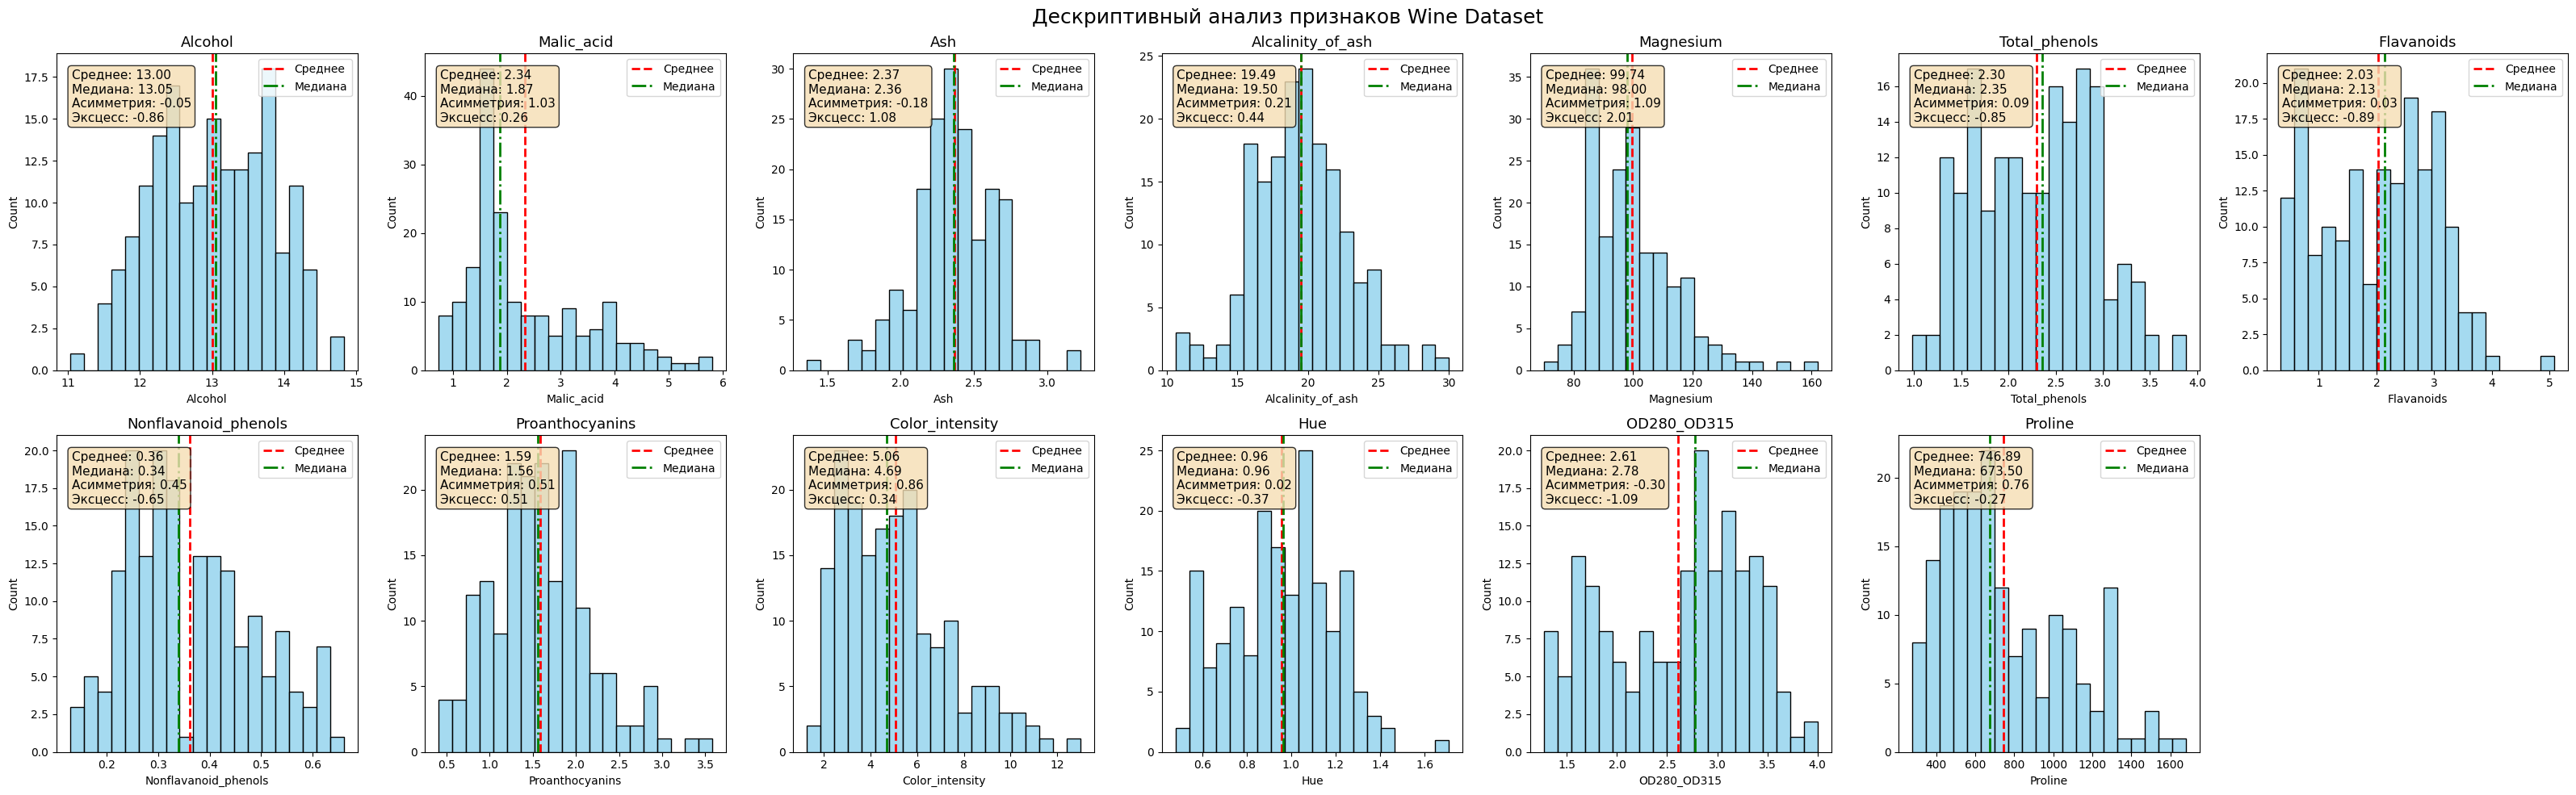

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import numpy as np

from scipy.stats import skew, kurtosis
columns = [
    'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash',
    'Magnesium', 'Total_phenols', 'Flavanoids',
    'Nonflavanoid_phenols', 'Proanthocyanins',
    'Color_intensity', 'Hue', 'OD280_OD315', 'Proline'
]

data = pd.read_csv('wine.data', header=None)
data.columns = ['Class'] + columns

X = data[columns]
numeric_cols = X.columns
fig, axes = plt.subplots(2, 7, figsize=(32, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data_col = X[col]
    
    mean_val = data_col.mean()
    median_val = data_col.median()
    skew_val = skew(data_col)
    kurt_val = kurtosis(data_col)
    
    sns.histplot(data_col, ax=axes[i], bins=20,
                 color='skyblue', edgecolor='black')
    
    axes[i].axvline(mean_val, color='red', linestyle='--',
                    linewidth=2, label=f'Среднее')
    axes[i].axvline(median_val, color='green', linestyle='-.',
                    linewidth=2, label=f'Медиана')
    
    stats_text = (
        f'Среднее: {mean_val:.2f}\n'
        f'Медиана: {median_val:.2f}\n'
        f'Асимметрия: {skew_val:.2f}\n'
        f'Эксцесс: {kurt_val:.2f}'
    )
    print(f'{col}\n')
    print(f'Среднее: {mean_val:.2f}\n')
    print( f'Медиана: {median_val:.2f}\n')
    print( f'Асимметрия: {skew_val:.2f}\n')
    print(f'Эксцесс: {kurt_val:.2f}')
    
    
    axes[i].text(
        0.05, 0.95, stats_text,
        transform=axes[i].transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    
    axes[i].set_title(col, fontsize=13)
    axes[i].legend()

# Убираем пустые оси
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Дескриптивный анализ признаков Wine Dataset', fontsize=18)
plt.tight_layout()
plt.show()


Для каждого числового признака были построены гистограммы распределений с наложением среднего и медианы, а также вычислены коэффициенты асимметрии и эксцесса.
Асимметрия измеряет симметрию распределения. Ноль означает идеальную симметрию (нормальное распределение).
Эксцесс измеряет остроту пика и тяжесть хвостов по сравнению с нормальным распределением (у которого эксцесс = 0).
Здесь значения ассиметрии варьируются от -0,30 до 1,09.
Некоторые переменные показывают умеренную асимметрию (например, Malic_acid: 1,03, Magnesium: 1,09, Color_intensity: 0,86).
Значение эксцесса от -1,09 до 2,01. Например, Magnesium имеет эксцесс 2,01, а OD280_OD315: -1,09.

Анализ показал, что для большинства признаков среднее значение не совпадает с медианой, что указывает на асимметрию распределений. Значения коэффициента асимметрии в ряде случаев существенно отличаются от нуля, что свидетельствует о скошенности распределений.
Для нормального распределения коэффициенты асимметрии и эксцесса должны быть близки к нулю. Полученные значения показывают, что данное условие не выполняется для большинства признаков, следовательно, распределения не согласуются с нормальным законом.


### Отбор и стандартизация признаков
Построим матрицу корреляции для всех признаков. Попытаемся убрать часть признаков для лучшей кластеризации.



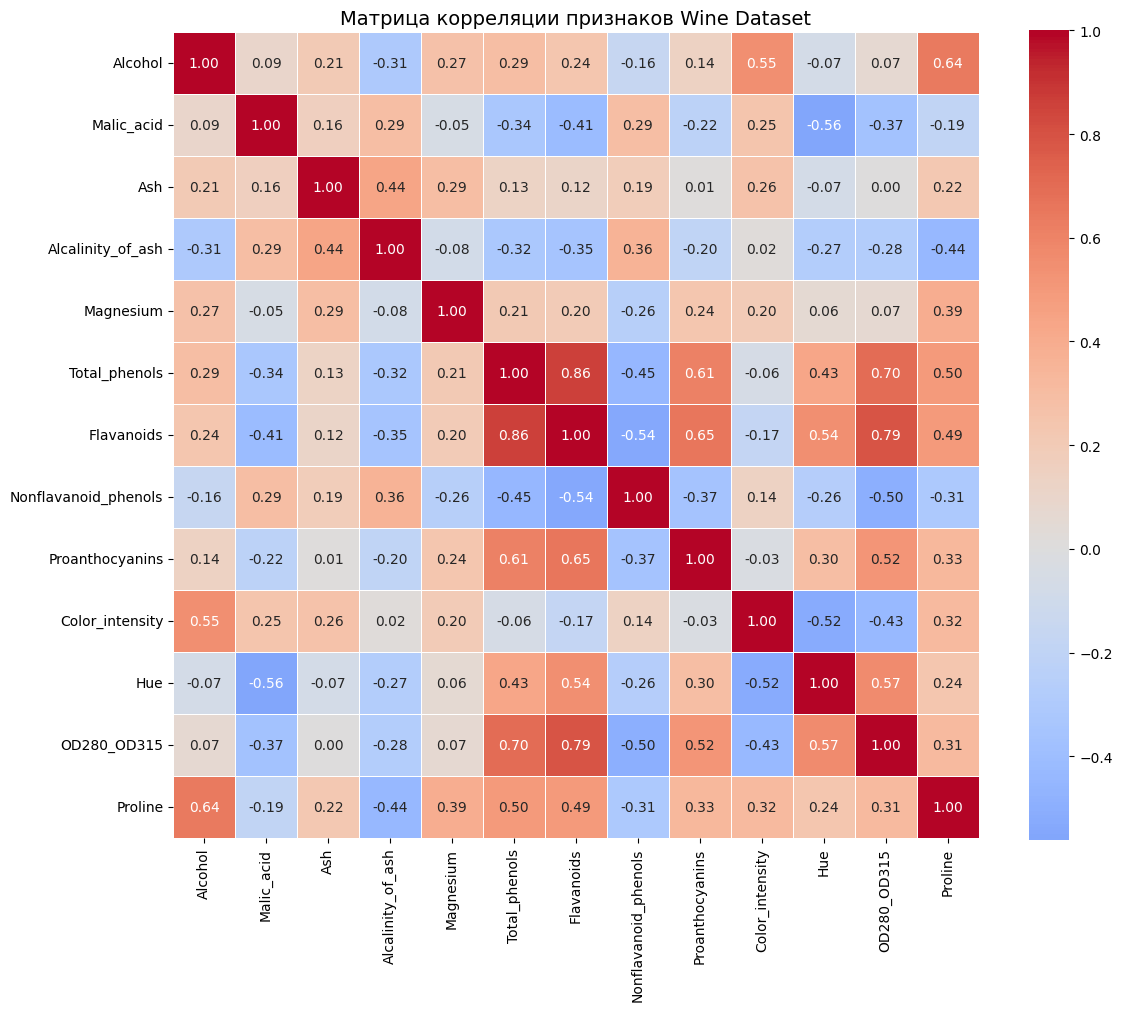

In [2]:

corr_matrix = X.corr(method='pearson')
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Матрица корреляции признаков Wine Dataset', fontsize=14)
plt.tight_layout()
plt.show()

Видно одну группу признаков с сильной корелляцией. Все они описывают фенолы. Это признаки:  
Total_phenols  - Flavanoids : Коэффициент коррелляции 0.86  
Flavanoids  - OD280_OD315: Коэффициент коррелляции  0.79  
Total_phenols - OD280_OD315: Коэффициент коррелляции 0.70  
Flavanoids – Proanthocyanins: Коэффициент коррелляции 0.65  

Признаки Total_phenols, Flavanoids, Proanthocyanins и OD280_OD315 характеризуют содержание фенольных соединений в вине. Между ними наблюдается высокая корреляция, поскольку они описывают один и тот же химический класс веществ с разных сторон. 
В целях уменьшения избыточности признаков для кластеризации был оставлен один наиболее информативный показатель (Flavanoids), а остальные исключены.

Другой важный признак — Nonflavanoid_phenols. У него отрицатеоьная корреляция с флаваноидами. Его оставлятем, он описывает противоположный химический аспект, полезный для кластеризации.

Также уберем признак Ash, так как его дублирует признак Alcalinity_of_ash.  
В итоге остается 9 признаков. Они не дублируют друг друга и выжны для дальнейшего анализа.


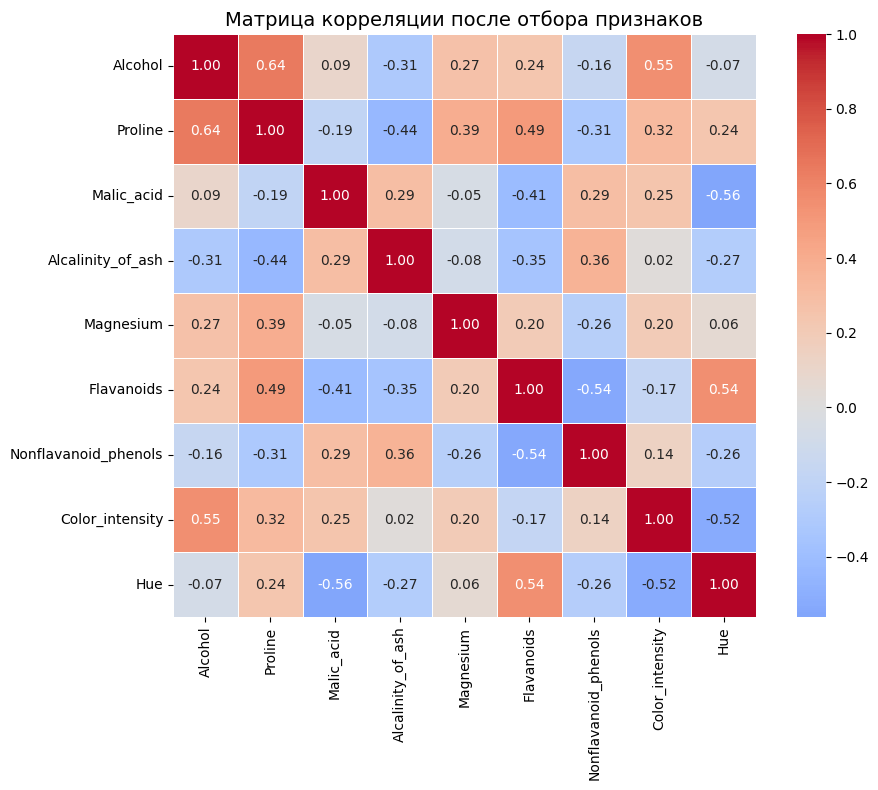

In [3]:
threshold = 0.75

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) >= threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ))

high_corr_pairs

selected_features = [
    'Alcohol',
    'Proline',
    'Malic_acid',
    'Alcalinity_of_ash',
    'Magnesium',
    'Flavanoids',
    'Nonflavanoid_phenols',
    'Color_intensity',
    'Hue'
]

X_selected = X[selected_features]
plt.figure(figsize=(10, 8))

sns.heatmap(
    X_selected.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Матрица корреляции после отбора признаков', fontsize=14)
plt.tight_layout()
plt.show()


Теперь построим диаграммы ящик с усами для выбранных признаков.

## Стандартизация и ящик с усами
Видно что значения признака Proline значительно больше, чем других признаков. А для кластеризации важно чтобы принаки имели одинаковый масштаб.
Также на рисунке наблюдаем большое количество выбросов, эти выбросы не аномальны (не являются ошибками измерения). Проведем стандартизацию признаков.
Из за выбросов будем использовать RobustScaler. Он не чуствителен к выбросам.  
Он работает так:  
- для каждого признака вычисляется медиана
- вычисляется межквартильный размах (мера разброса центральных 50% данных)
- значения пересчитываются относительно этих величин (центрирование и масштабирование)
Формула стандартизации:  

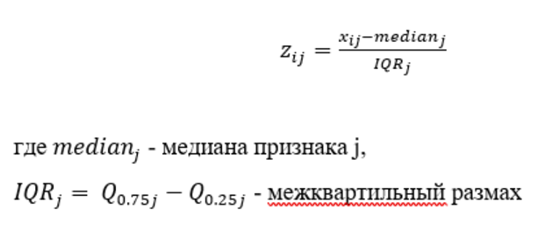

C:\Users\nikit\AppData\Local\Temp\ipykernel_5588\201153936.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


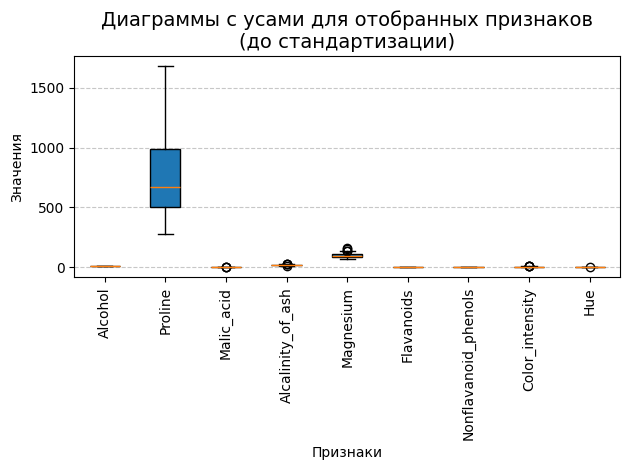

C:\Users\nikit\AppData\Local\Temp\ipykernel_5588\201153936.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


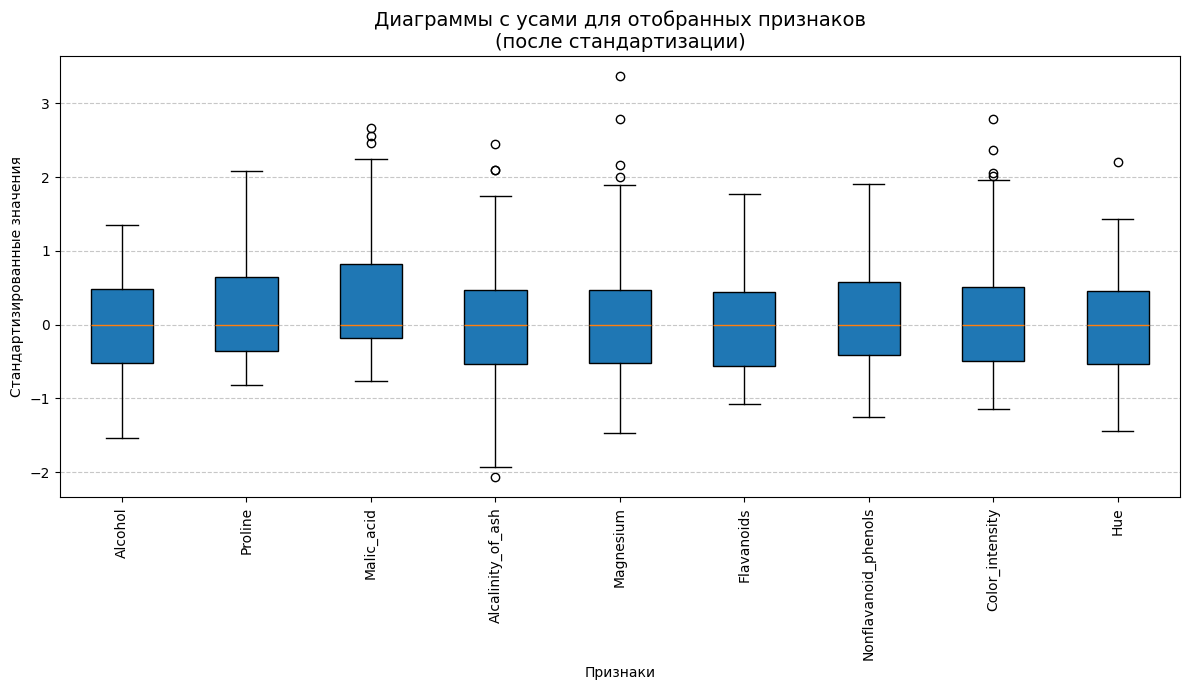

In [16]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import pandas as pd

X_selected = X_selected.copy()

plt.boxplot(
    X_selected.values,
    vert=True,
    labels=X_selected.columns,
    patch_artist=True
)

plt.xticks(rotation=90)
plt.title('Диаграммы с усами для отобранных признаков\n(до стандартизации)', fontsize=14)
plt.xlabel('Признаки')
plt.ylabel('Значения')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

scaler = RobustScaler()
X_std = scaler.fit_transform(X_selected)

X_std = pd.DataFrame(X_std, columns=X_selected.columns)

plt.figure(figsize=(12, 7))

plt.boxplot(
    X_std.values,
    vert=True,
    labels=X_std.columns,
    patch_artist=True
)

plt.xticks(rotation=90)
plt.title('Диаграммы с усами для отобранных признаков\n(после стандартизации)', fontsize=14)
plt.xlabel('Признаки')
plt.ylabel('Стандартизированные значения')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Видно что теперь масштаб признаков совпадает.

### Диаграммы рассеяния
Построим попарные диаграммы рассеивания, в том числе категориальные.

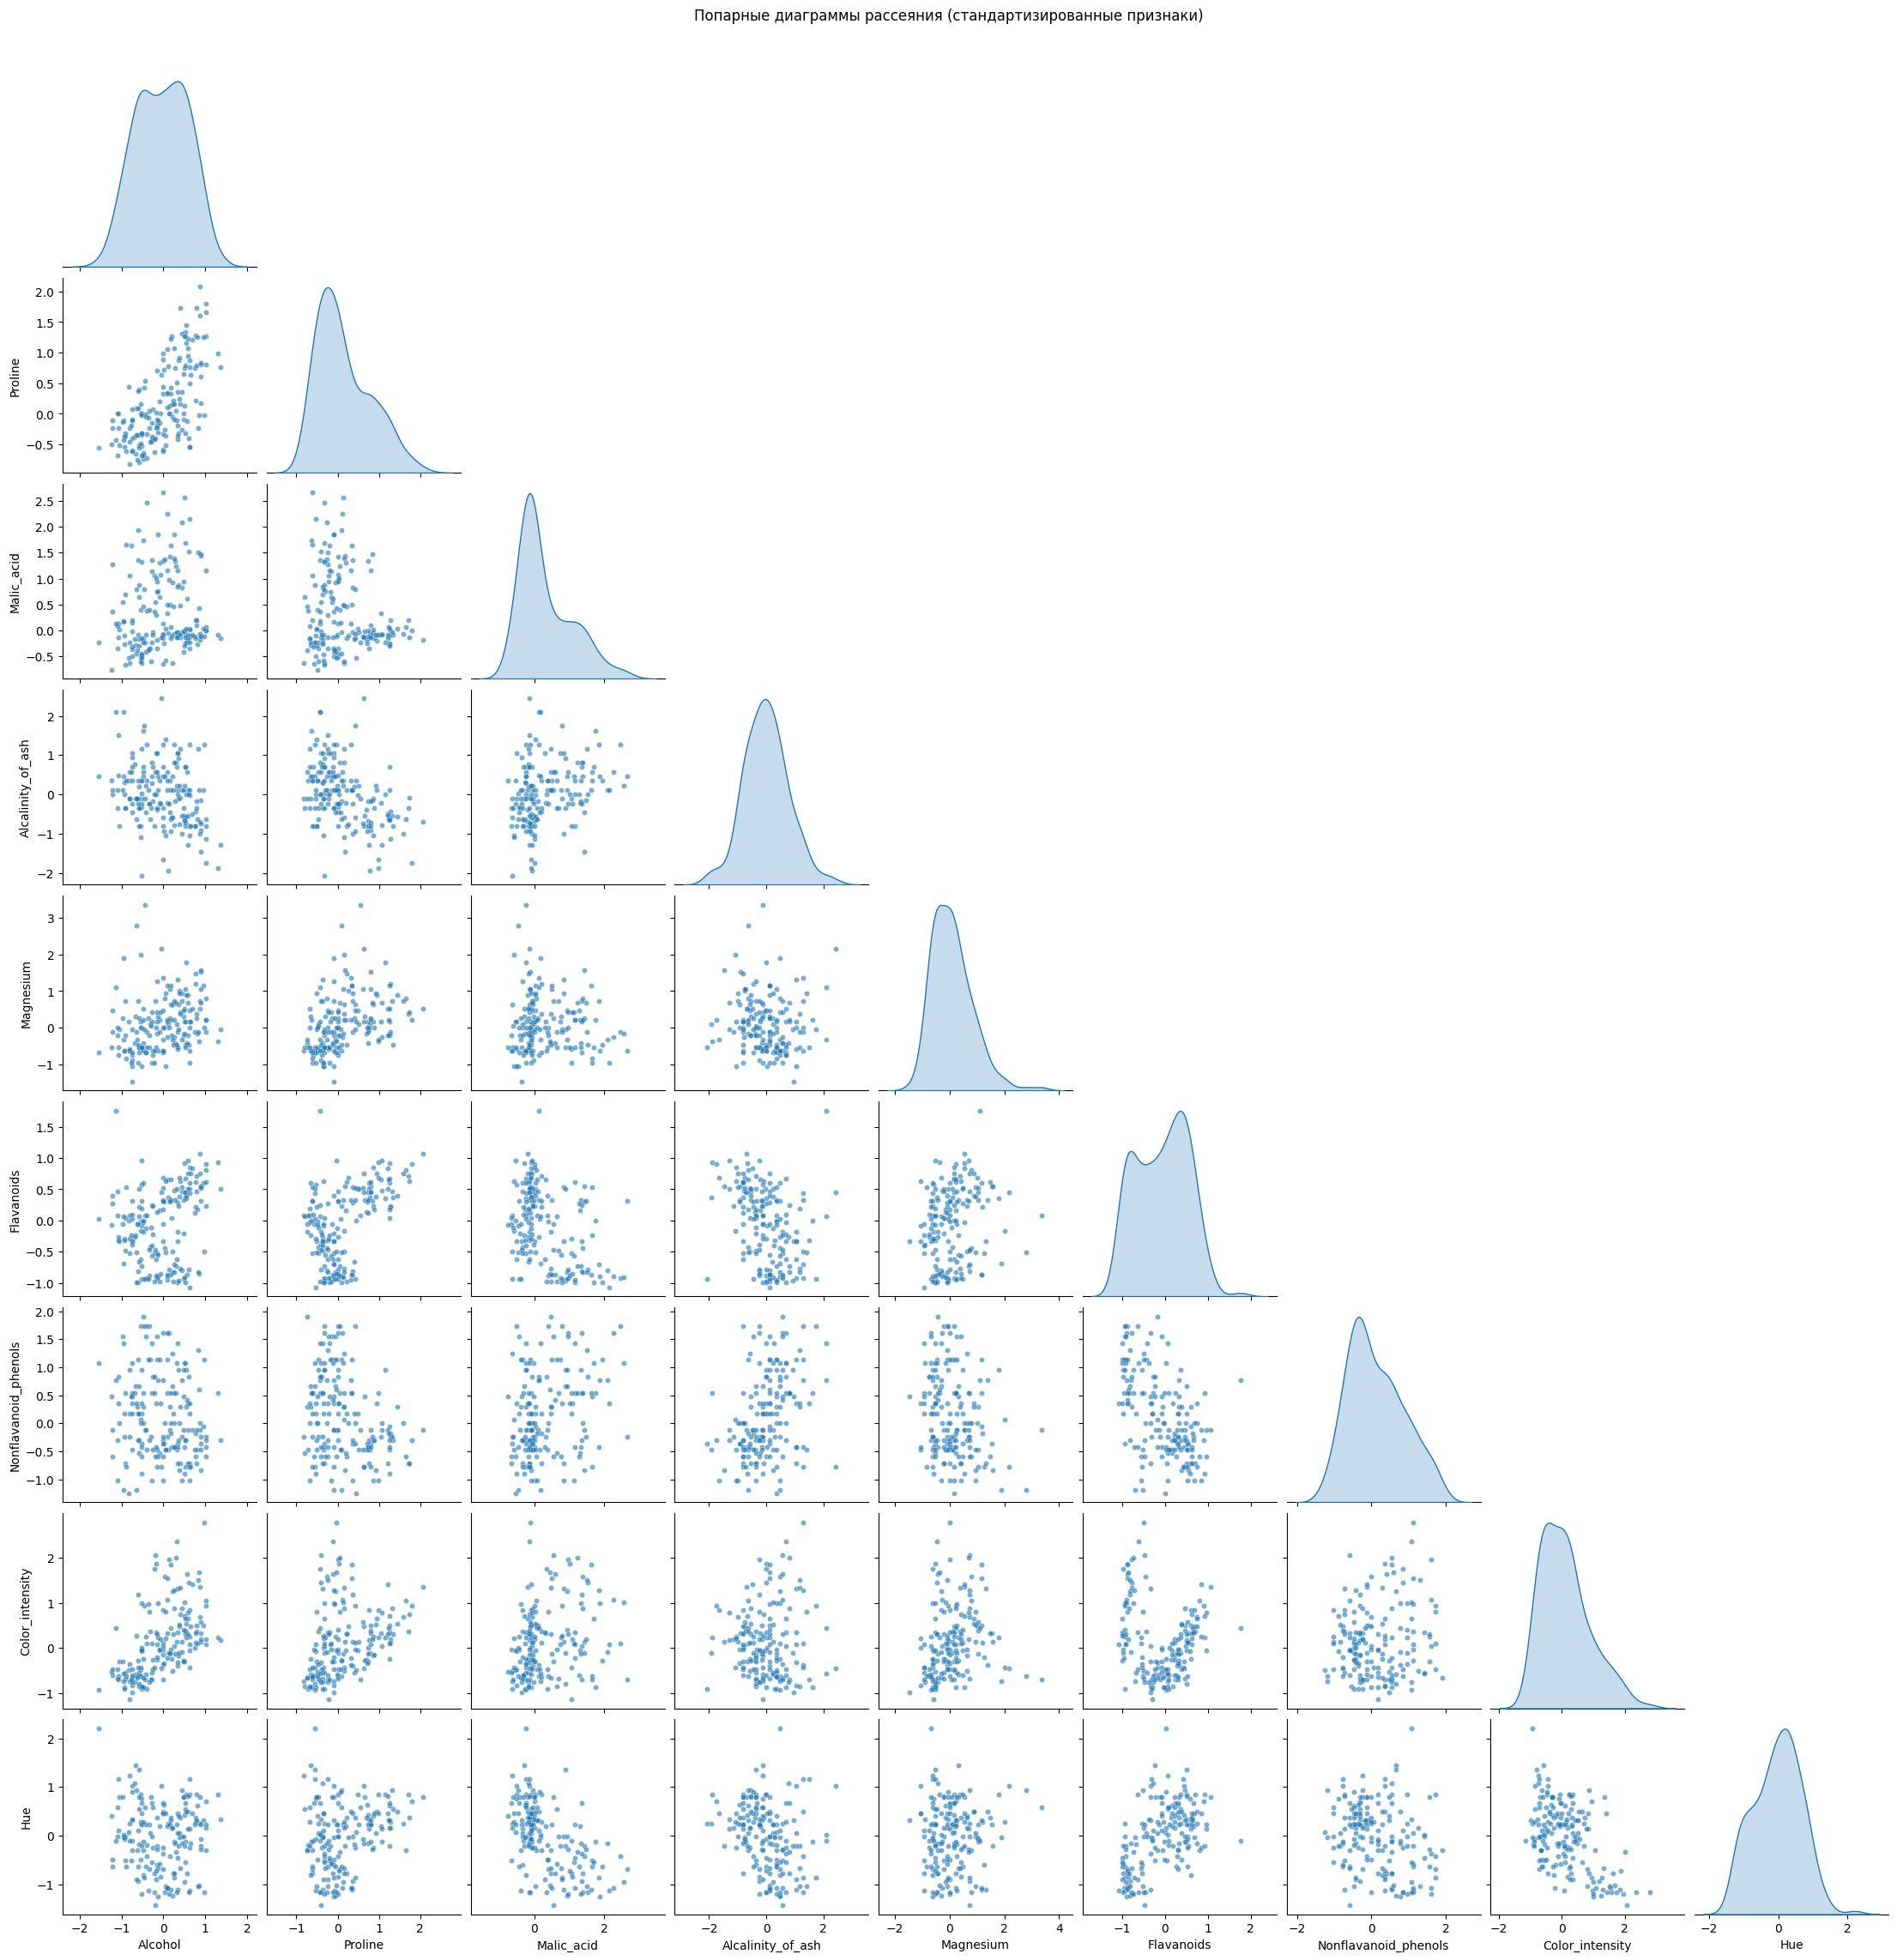

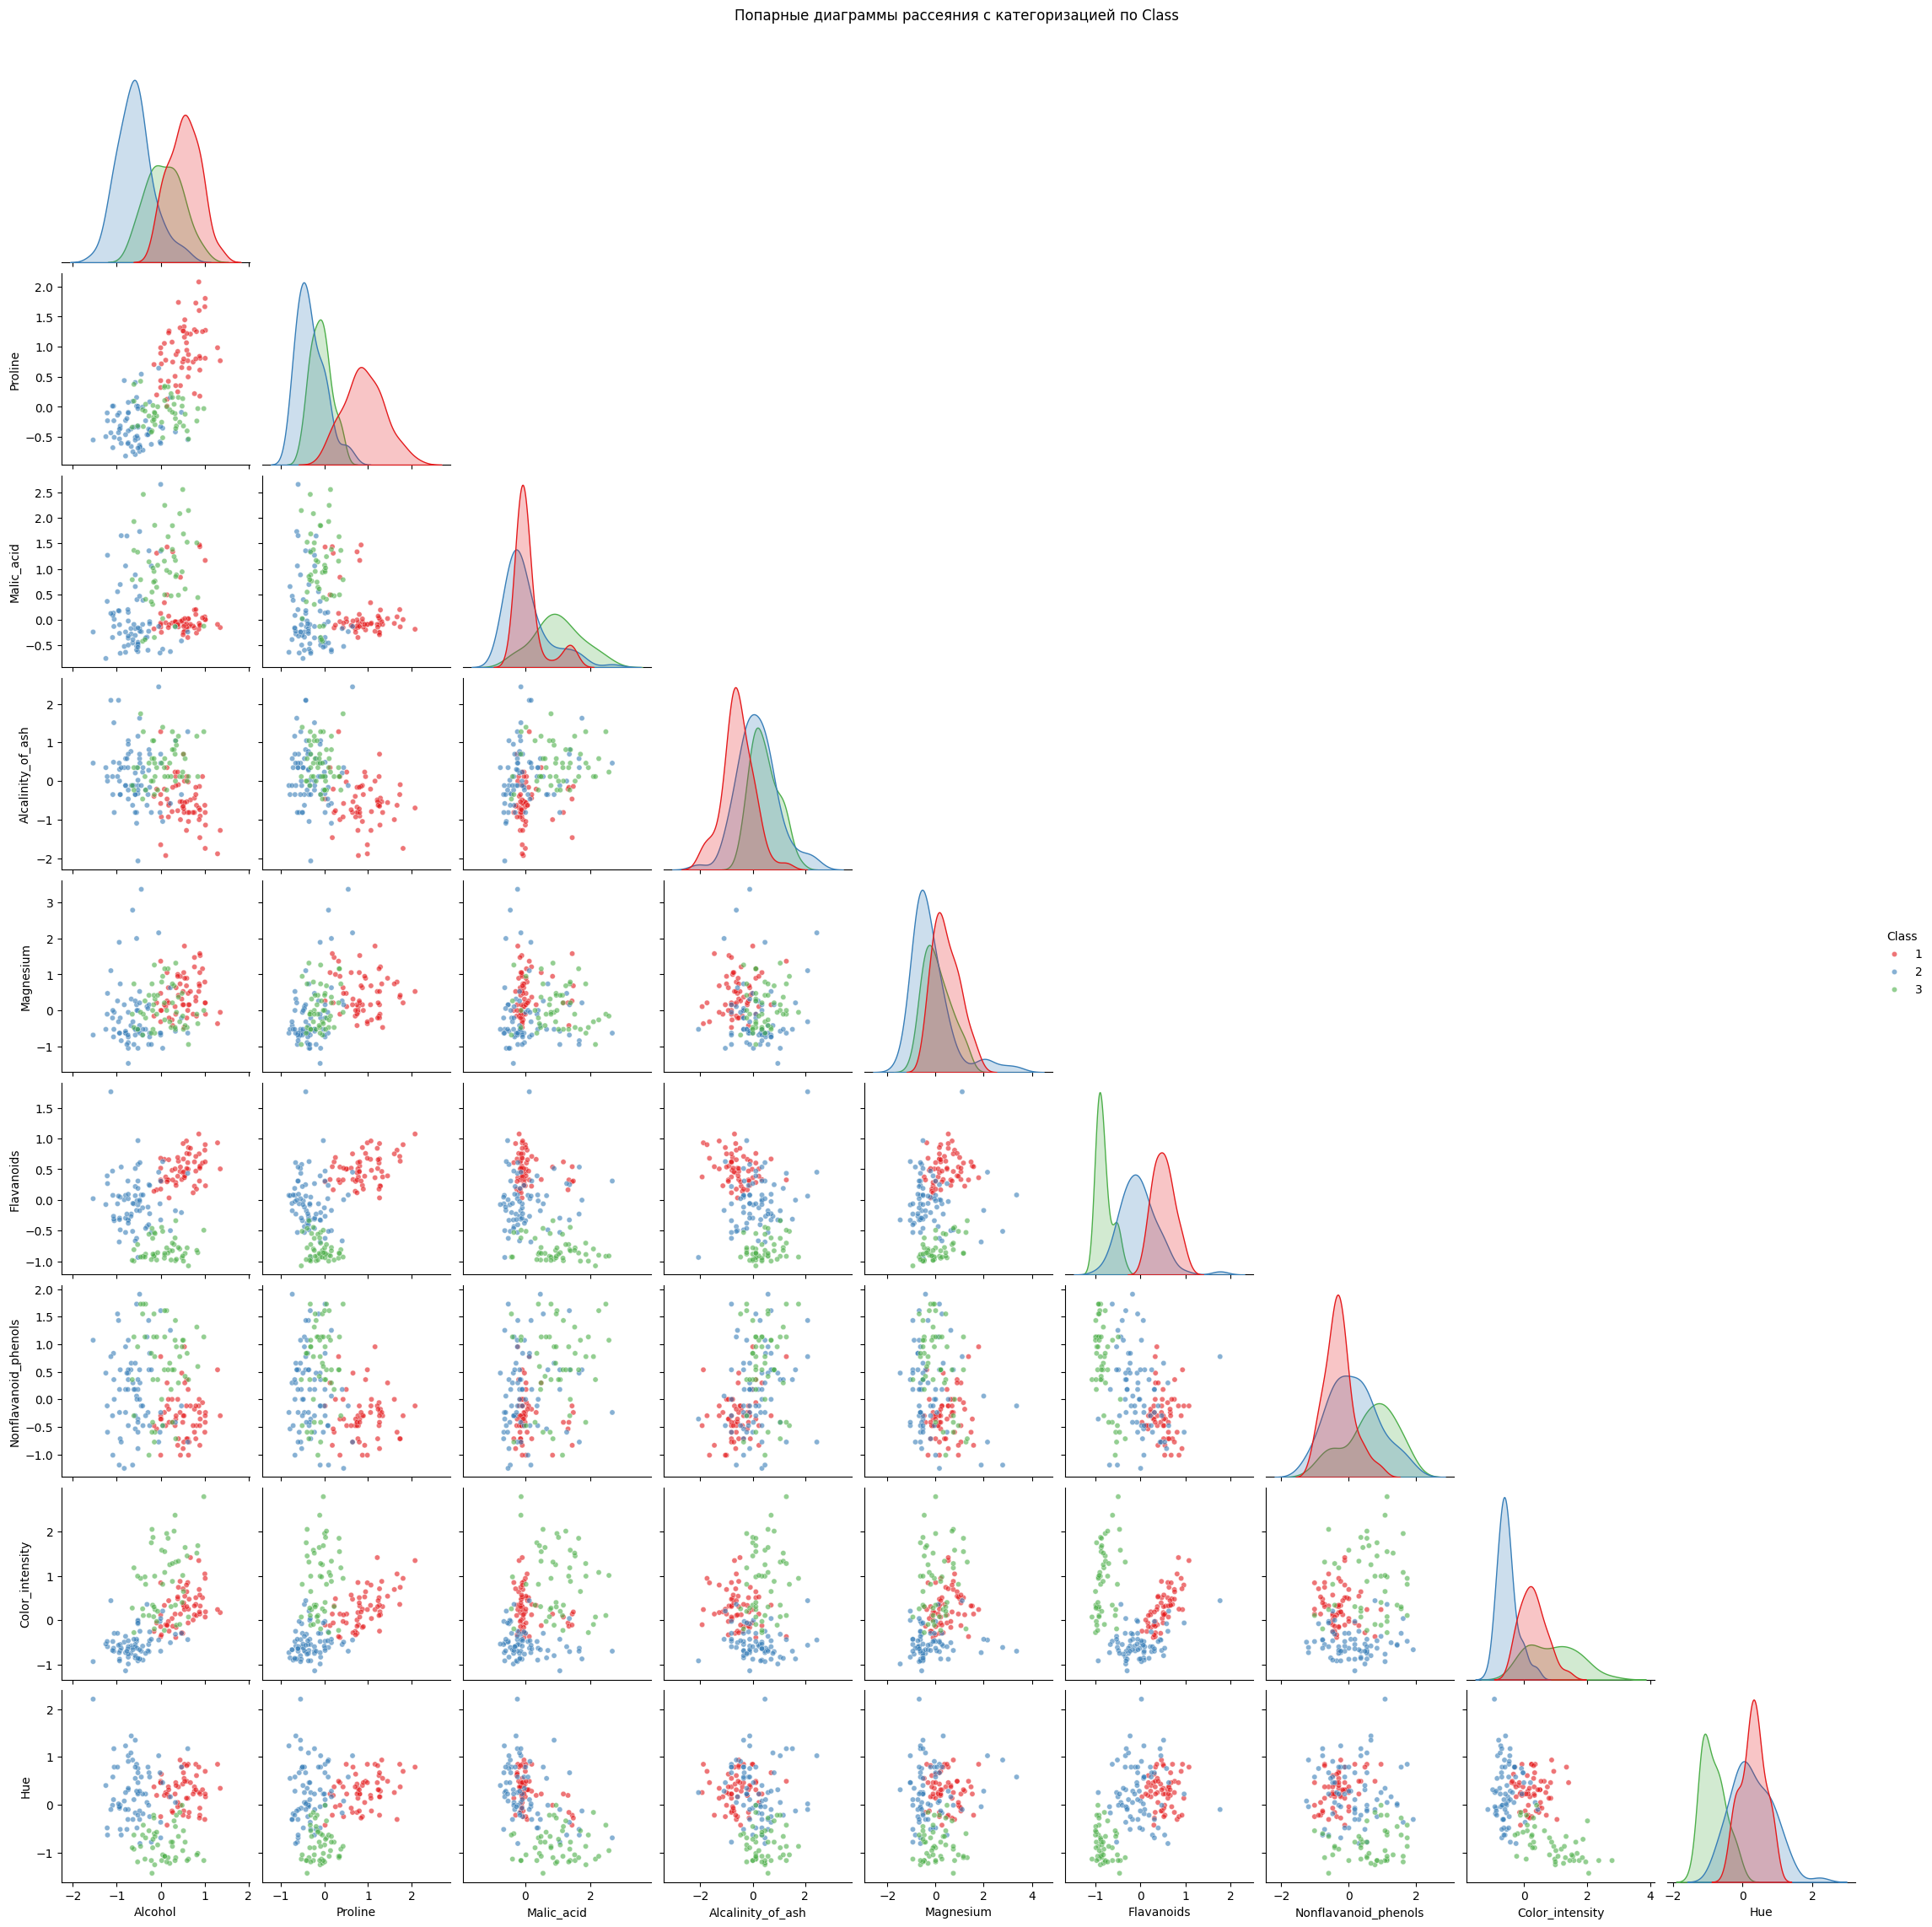

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X_selected_std = X_std.copy()
X_selected_std['Class'] = data['Class']
sns.pairplot(
    X_selected_std,
    vars=X_selected_std.columns[:-1],
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 20}
)
plt.suptitle("Попарные диаграммы рассеяния (стандартизированные признаки)", y=1.02)
plt.show()
sns.pairplot(
    X_selected_std,
    vars=X_selected_std.columns[:-1],
    hue="Class",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 20},
    palette="Set1"
)
plt.suptitle("Попарные диаграммы рассеяния с категоризацией по Class", y=1.02)
plt.show()


На пересечении находятся диаграммы рассеяния для двух признаков. На диагонали находятся одномерные распределения каждого признака.

На большинстве диаграмм кластеры сильно перекрываются, видно одно эллиптическое облако.  Видимо центры кластеров близки друг к другу относительно разброса данных.
Теперь построим диаграммы рассеивания с категоризацией.
В то же время на диаграммах с категоризацией точки четко группируются по классам. Видно, что некоторые признаки имеют чёткие различия между классами, например: flavanoids — четко видно 3 кластера.  
Proline - хорошо разделяет синий и красный классы, зеленый тоже частично отделён.  
Alcohol — хорошо разделяет красный и синий кластер, но зеленый кластер пересекается.  
Признаки Magnesium, Nonflavanoid_phenols,Proanthocyanins дают сильное перекрытие, кластеры по этим признакам плохо различимы.  

Оценим тип кластерной структуры.  
Форма - Эллиптическая/вытянутая форма для большинства признаков (Proline и Flavanoids).  
Количество кластеров сложно определить визуально по диаграммам рассеяния. Известно, что данные разделяются на три класса (так как есть метки), но из диаграмм это не  видно.  

Следовательно нам подходят следующие методы:  
K – средних, как базовый метод кластеризации. Подходит для признаков с компактными, круглой формой кластерами.  
GMM — так как он лучше справляется с кластерами эллиптической формы и для перекрывающихся кластеров, а у нас именно такие.  
DBSCAN  - не подойдёт, потому что он ищет области высокой плотности, разделённые пустотами, а у вас одно сплошное плотное облако. Алгоритм увидит один большой кластер или разобьёт его на кластеры с шумом произвольным образом  
Иерархическая кластеризация – не будем использовать, так как нет иерархии данных.  


### Подбор числа кластеров
В качестве метрики расстояния между точками будем использовать евклидово расстояние. Оно рассчитывается по следующей формуле:  
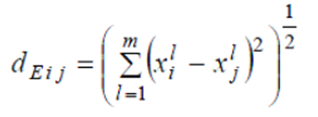

Для K-means самым важным параметром является число кластеров.   
Определим оптимальное число кластеров.  
Построим различные метрики качества k-means для разных k.

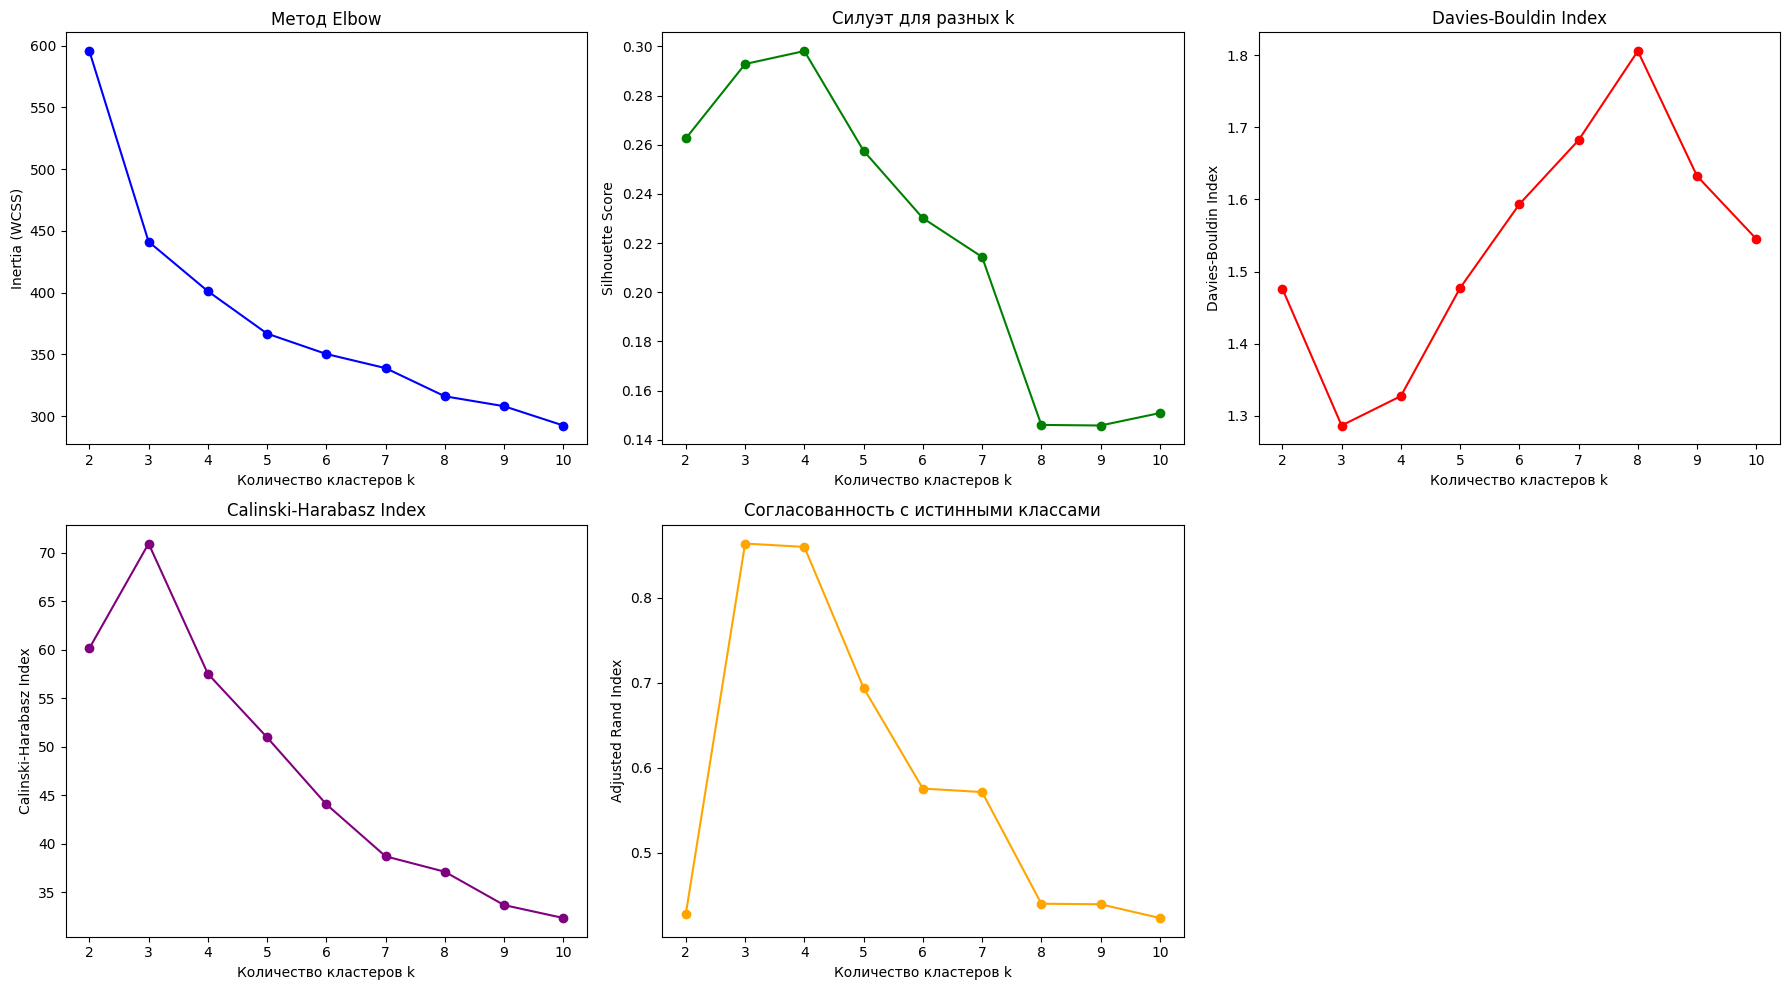

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, silhouette_score

y_true = X_selected_std['Class']
X_cluster = X_selected_std.drop(columns=['Class'])
K_range = range(2, 11)
dbi_scores = []
chi_scores = []
ari_scores = []
inertia = []
silhouette = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=52)
    kmeans.fit(X_cluster)
    labels = kmeans.labels_
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_cluster, labels))
    
    dbi_scores.append(davies_bouldin_score(X_cluster, labels))
    chi_scores.append(calinski_harabasz_score(X_cluster, labels))
    ari_scores.append(adjusted_rand_score(y_true, labels))

plt.figure(figsize=(18,10))

# Локоть
plt.subplot(2,3,1)
plt.plot(K_range, inertia, 'o-', color='blue')
plt.xlabel('Количество кластеров k')
plt.ylabel('Inertia (WCSS)')
plt.title('Метод Elbow')

# Silhouette
plt.subplot(2,3,2)
plt.plot(K_range, silhouette, 'o-', color='green')
plt.xlabel('Количество кластеров k')
plt.ylabel('Silhouette Score')
plt.title('Силуэт для разных k')

# Davies-Bouldin Index
plt.subplot(2,3,3)
plt.plot(K_range, dbi_scores, 'o-', color='red')
plt.xlabel('Количество кластеров k')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index')

# Calinski-Harabasz Index
plt.subplot(2,3,4)
plt.plot(K_range, chi_scores, 'o-', color='purple')
plt.xlabel('Количество кластеров k')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Index')

# Adjusted Rand Index
plt.subplot(2,3,5)
plt.plot(K_range, ari_scores, 'o-', color='orange')
plt.xlabel('Количество кластеров k')
plt.ylabel('Adjusted Rand Index')
plt.title('Согласованность с истинными классами')

plt.tight_layout()
plt.show()




Для построения графика локтя для каждого k вычисляем WCSS сумму квадратов расстояний от точек до центров их кластеров по следующей формуле:  
 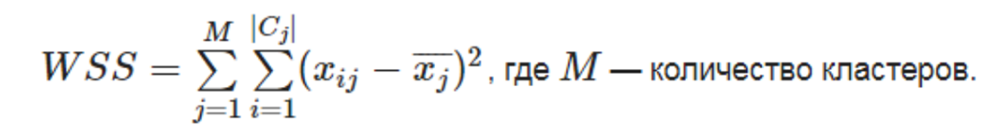

Далее ищем локоть - точку, после которой график перестает резко падать и начинает снижаться почти линейно. На нашем графике это происходит при k = 3.

Для построения графика силуэта для каждой точки данных вычисляют силуэтный коэффициент. Он вычисляется по следующей формуле:  
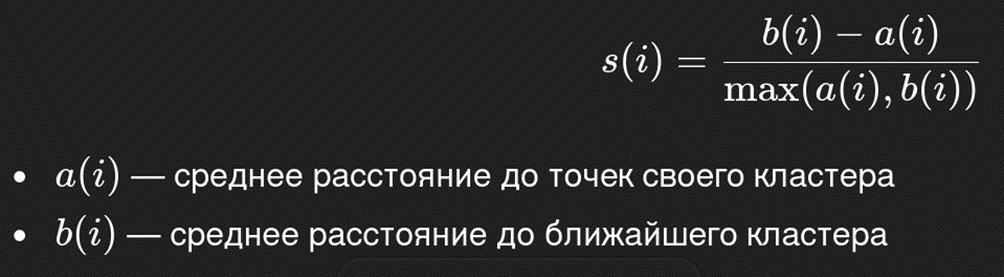

 
Из графика видно, что наибольший коэффициент силуэта достигается при k = 3  

Считаем индекс Дэвиса–Болдина для каждого k. Он измеряет соотношение внутрикластерного разброса и расстояния между кластерами. Наилучший результат при k = 3  

Далее рассчитываем индекс Калински–Харабаса. Он сравнивает межкластерную дисперсию с внутрикластерной дисперсией. Наибольший индекс при k=3.  
Далее, так как известны метки истиных классов, можно посчитать ARI для разных k. Он показывает насколько согласованы метки кластеров и истиных классов. Максимальная согласованность достигается при k=3  
В итоге все методы дают значение k=3, его и будем использовать в k-means.  


### Задача классификации k-means

Метрики KMeans (k = 3):
Средний силуэт           : 0.2931
Индекс Калински–Харабаса : 71.0148
Индекс Дэвиса–Болдина    : 1.2881
ARI                      : 0.8486


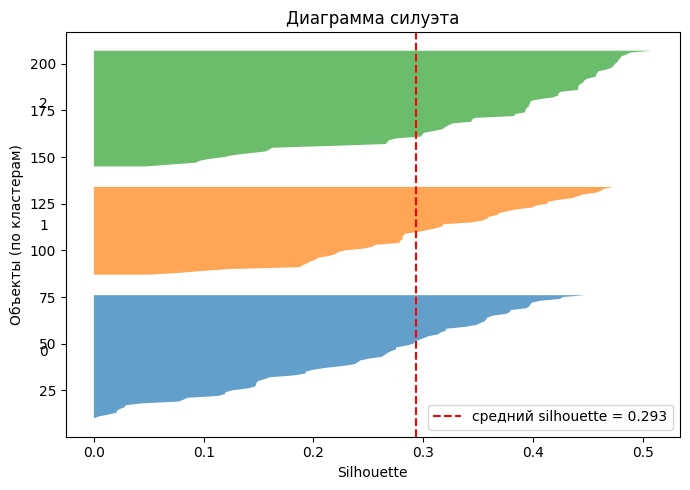


Центры кластеров (в пространстве стандартизованных признаков):


,Alcohol,Proline,Malic_acid,Alcalinity_of_ash,Magnesium,Flavanoids,Nonflavanoid_phenols,Color_intensity,Hue
cluster_0,-0.602690,-0.340234,0.005294,0.167650,-0.316575,-0.040888,0.194253,-0.529150,0.258308
cluster_1,0.090463,-0.106553,1.091920,0.486919,0.029605,-0.780439,0.654229,0.893107,-0.832716
cluster_2,0.465930,0.871017,0.062259,-0.552602,0.573099,0.459224,-0.336413,0.231277,0.296531


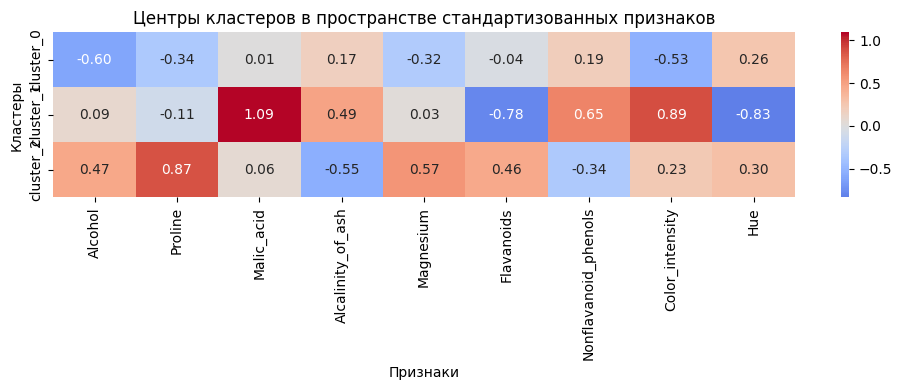


Характеристики кластеров (внутрикластерные расстояния / компактность):


,cluster,size,mean_dist_to_center,std_dist_to_center,within_cluster_SSE
0,0,67,1.546587,0.536255,179.526616
1,1,48,1.545730,0.422329,123.246851
2,2,63,1.361495,0.585595,138.385185



Расстояния между центрами кластеров (евклидовы):


,cluster_0,cluster_1,cluster_2
cluster_0,0.000000,2.430896,2.243666
cluster_1,2.430896,0.000000,2.786426
cluster_2,2.243666,2.786426,0.000000


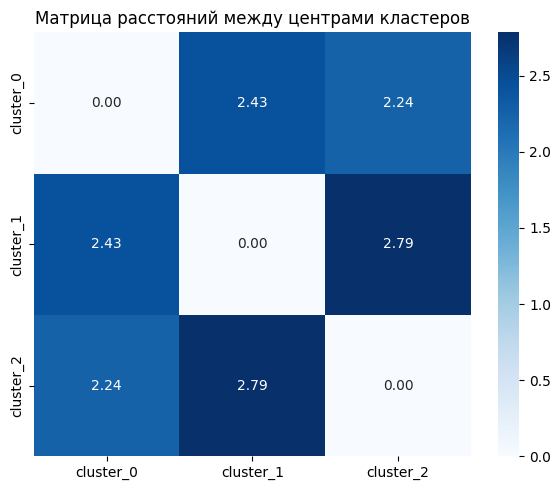


Значимость признаков по кластерам (односторонний ANOVA, KMeans):


,feature,F_stat,p_value
0,Alcohol,113.925482,2.068682e-32
1,Proline,199.946291,6.338588e-46
2,Malic_acid,56.154486,1.446356e-19
3,Alcalinity_of_ash,38.296084,1.602623e-14
4,Magnesium,30.661443,3.837722e-12
5,Flavanoids,171.399169,5.980978e-42
6,Nonflavanoid_phenols,33.705455,4.144910e-13
7,Color_intensity,102.160605,4.005952e-30
8,Hue,99.540286,1.353251e-29


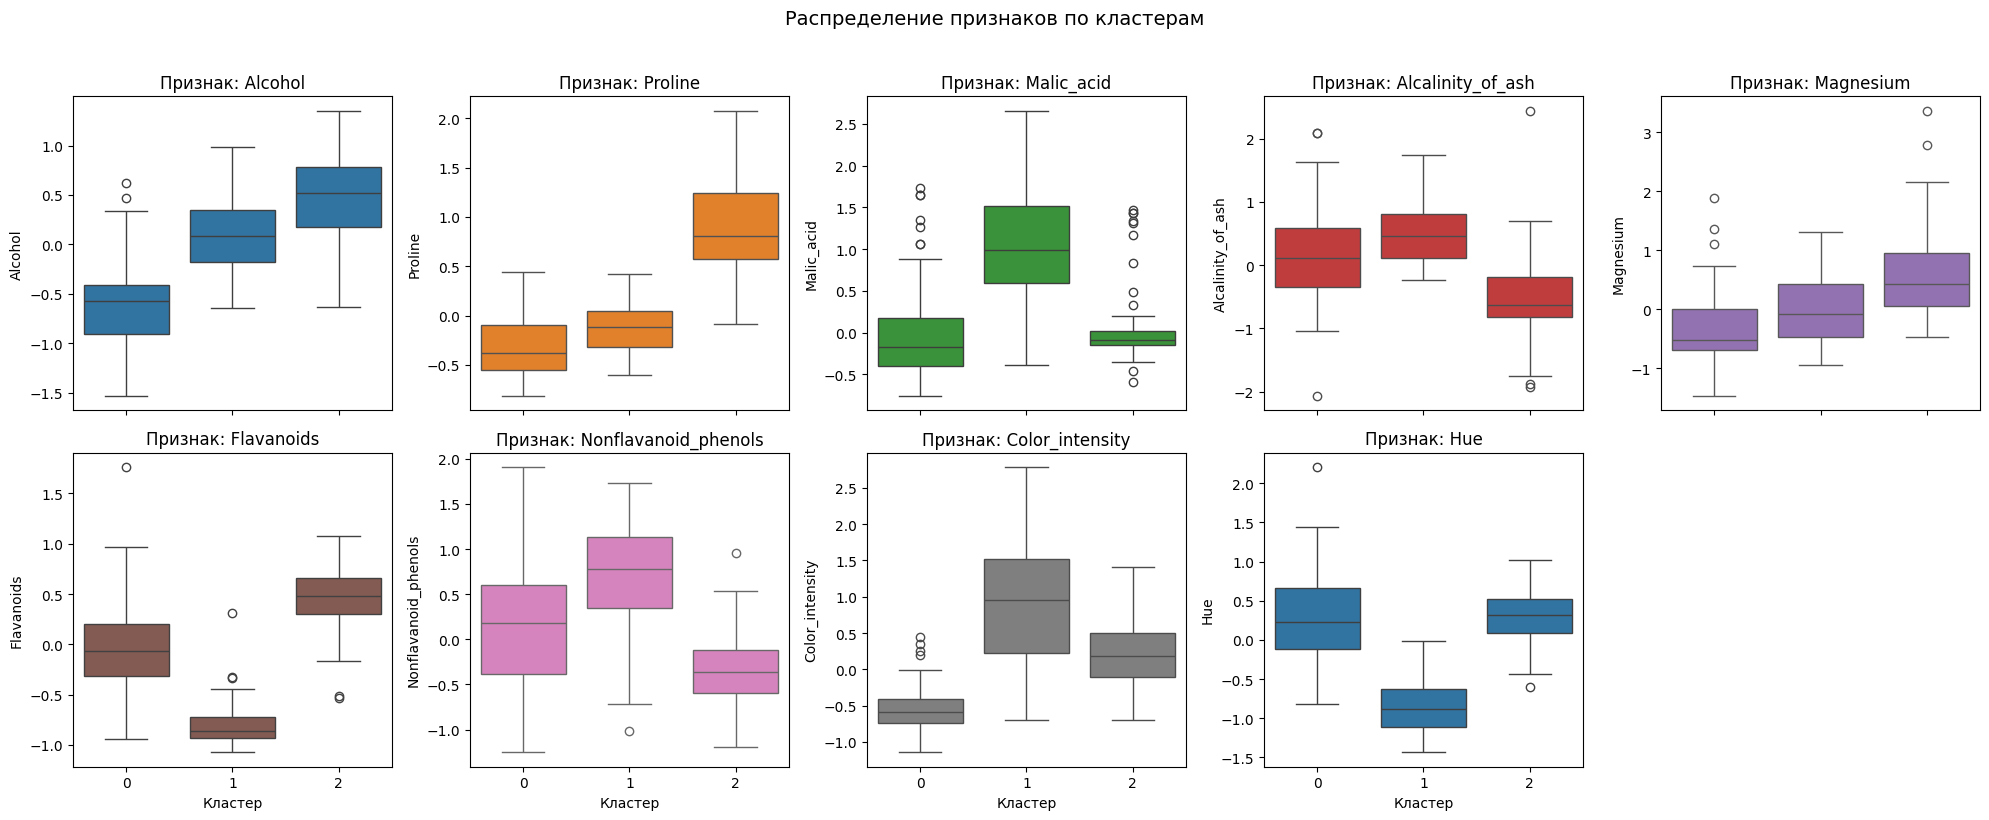

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_samples,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    pairwise_distances,
)
from scipy.stats import f_oneway
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# используем стандартизированные признаки
X_scaled = X_std.copy()
y_true = X_selected_std['Class'] = data['Class']

# количество кластеров
k = 3

kmeans = KMeans(
    n_clusters=k,
    init="k-means++",
    n_init=10,
    random_state=52,
)
kmeans.fit(X_scaled)
labels = kmeans.labels_

# метрики качества
sil_samples = silhouette_samples(X_scaled, labels)
sil = silhouette_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ari = adjusted_rand_score(y_true, labels)

print(f"Метрики KMeans (k = {k}):")
print(f"Средний силуэт           : {sil:.4f}")
print(f"Индекс Калински–Харабаса : {ch:.4f}")
print(f"Индекс Дэвиса–Болдина    : {db:.4f}")
print(f"ARI                      : {ari:.4f}")

# Диаграмма силуэта
fig, ax = plt.subplots(figsize=(7, 5))

y_lower = 10
for c in range(k):
    sil_c = sil_samples[labels == c]
    sil_c.sort()
    size_c = sil_c.shape[0]
    y_upper = y_lower + size_c

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, sil_c,
        alpha=0.7,
    )
    ax.text(-0.05, y_lower + 0.5 * size_c, str(c))
    y_lower = y_upper + 10

ax.axvline(x=sil, color="red", linestyle="--",
           label=f"средний silhouette = {sil:.3f}")
ax.set_title(f"Диаграмма силуэта")
ax.set_xlabel("Silhouette")
ax.set_ylabel("Объекты (по кластерам)")
ax.legend(loc="best")

plt.tight_layout()
plt.show()

# Центры кластеров и внутрикластерные расстояния
centers = kmeans.cluster_centers_ 

print("\nЦентры кластеров (в пространстве стандартизованных признаков):")
centers_df = pd.DataFrame(centers, columns=X_scaled.columns)
centers_df.index = [f"cluster_{c}" for c in range(k)]
display(centers_df)

plt.figure(figsize=(10, 4))
sns.heatmap(
    centers_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Центры кластеров в пространстве стандартизованных признаков")
plt.xlabel("Признаки")
plt.ylabel("Кластеры")
plt.tight_layout()
plt.show()

# расстояния от объектов до центров
dist_to_centers = pairwise_distances(X_scaled, centers)

cluster_stats = []
for c in range(k):
    mask = (labels == c)
    n_c = mask.sum()
    if n_c == 0:
        mean_dist = np.nan
        std_dist = np.nan
        sse_c = np.nan
    else:
        dists_c = dist_to_centers[mask, c]
        mean_dist = dists_c.mean()
        std_dist = dists_c.std()
        sse_c = (dists_c ** 2).sum()

    cluster_stats.append({
        "cluster": c,
        "size": n_c,
        "mean_dist_to_center": mean_dist,
        "std_dist_to_center": std_dist,
        "within_cluster_SSE": sse_c,
    })

print("\nХарактеристики кластеров (внутрикластерные расстояния / компактность):")
cluster_stats_df = pd.DataFrame(cluster_stats)
display(cluster_stats_df)

# расстояния между центрами кластеров
center_dists = pairwise_distances(centers, centers)
center_dists_df = pd.DataFrame(
    center_dists,
    index=[f"cluster_{c}" for c in range(k)],
    columns=[f"cluster_{c}" for c in range(k)]
)

print("\nРасстояния между центрами кластеров (евклидовы):")
display(center_dists_df)

plt.figure(figsize=(6, 5))
sns.heatmap(center_dists_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Матрица расстояний между центрами кластеров")
plt.tight_layout()
plt.show()

X_df = X_scaled.copy()
X_df["cluster"] = labels
X_df["class"] = y_true

feature_cols = [c for c in X_df.columns if c not in ["cluster", "class"]]

anova_rows = []
for feat in feature_cols:
    groups = [X_df.loc[labels == c, feat] for c in range(k) if (labels == c).sum() > 1]
    if len(groups) > 1:
        F, p = f_oneway(*groups)
    else:
        F, p = np.nan, np.nan
    anova_rows.append({
        "feature": feat,
        "F_stat": F,
        "p_value": p,
    })

anova_df = pd.DataFrame(anova_rows)
print("\nЗначимость признаков по кластерам (односторонний ANOVA, KMeans):")
display(anova_df)

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red",
          "tab:purple", "tab:brown", "tab:pink", "tab:gray"]

n_feats = len(feature_cols)
n_rows = 2
n_cols = int(np.ceil(n_feats / n_rows))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharex=True)
axes = np.array(axes).ravel()

for i, feat in enumerate(feature_cols):
    ax = axes[i]
    sns.boxplot(
        data=X_df,
        x="cluster",
        y=feat,
        ax=ax,
        color=colors[i % len(colors)],
    )
    ax.set_title(f"Признак: {feat}")
    ax.set_xlabel("Кластер")
    ax.set_ylabel(feat)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Распределение признаков по кластерам", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### Оценка адекватности полученных решений для метода K-means
Была решена задача классификации методом k-means с k = 3 и евклидовой метрикой.
Посмотрим на расстояние между кластерами и на внутрикластерные расстояния.
 
Среднее расстояние до центра (mean_dist_to_center) -  очень близкие значения (1.36 -1.55) для всех трёх кластеров. Это говорит о том, что в среднем точки находятся на примерно одинаковом расстоянии от своих центроидов. Компактность кластеров по этому показателю сопоставима.  

Стандартное отклонение расстояния (std_dist_to_center): Показывает разброс точек внутри кластера. Кластер 2 имеет наибольшее std (0.586), что указывает на наибольшую неоднородность (размытость) его формы.  

 
Расстояния между центрами: Все значения находятся в диапазоне  2.24 - 2.79. Это больше, чем средние расстояния внутри кластеров (~1.4) примерно в 1.5-1.8 раза. Наибольшее расстояние между кластерами 1 и 2 (2.79), наименьшее — между 0 и 2 (2.24).

Теперь проанализируем компактность кластеров. Посчитаем Индекс Калински-Харабаса. Он показывает отношение межкластерной дисперсии (разделимости кластеров) к внутрикластерной дисперсии (компактности). Чем выше значение, тем лучше разделены кластеры.

В нашем случае CHI = 71.0148. Оно означает, что кластеры хорошо отделены друг от друга (межкластерная дисперсия значительно превышает внутрикластерную). 

В то же время был посчитан индекс Дэвиса-Болдина. Его значение DBI = 1.288
Она измеряет среднее отношение внутрикластерного разброса к межкластерному разделению. Чем ниже значение, тем лучше. Значение 1.288 является относительно высоким, значит кластеры имеют не очень хорошую компактность.  
Далее посчитаем средний силуэт и построим диаграмму силуэта.   
Средний силуэт равен 0.293 Это среднее значение.  
Силуэт показывает, насколько объект похож на свой собственный кластер по сравнению с другими кластерами. По диаграмме видно, что нет точек которые бы попали не в свой кластер. Наибольшее значение силуэта у первого кластера.

 

Далее посчитаем Adjusted Rand Index, так как у нас есть метки истиных классов. Он измеряет сходство между предсказанной и истинной кластеризацией, с поправкой на случайность. Значение, близкое к 1 означает почти полное совпадение. Получаем такие распределения:
 

ARI равен 0.84 Это хороший результат. Значение, близкое к 1 , означает большой процент совпадений, что видно и из диаграмм рассеивания для k-means и истиными классами.

В итоге можно сделать такие выводы:
K-means хорошо определил кластеры с точки зрения истинной структуры данных (ARI  = 0.85). Алгоритм верно уловил разделение. Высокий CHI показывает, что кластеры далеко друг от друга. Но низкий DBI и Silhouette говорят что кластеры не очень плотные и их границы размыты.
Видимо центры кластеров находятся на расстоянии, но сами кластеры имеют размазанную форму и возможно, вытянуты в направлении друг друга.
KMeans строит сферические кластеры. Данные, судя по метрикам, не идеально соответствуют этой модели. Кластеры, особенно 2-й, скорее всего, эллипсоидной или более сложной формы.


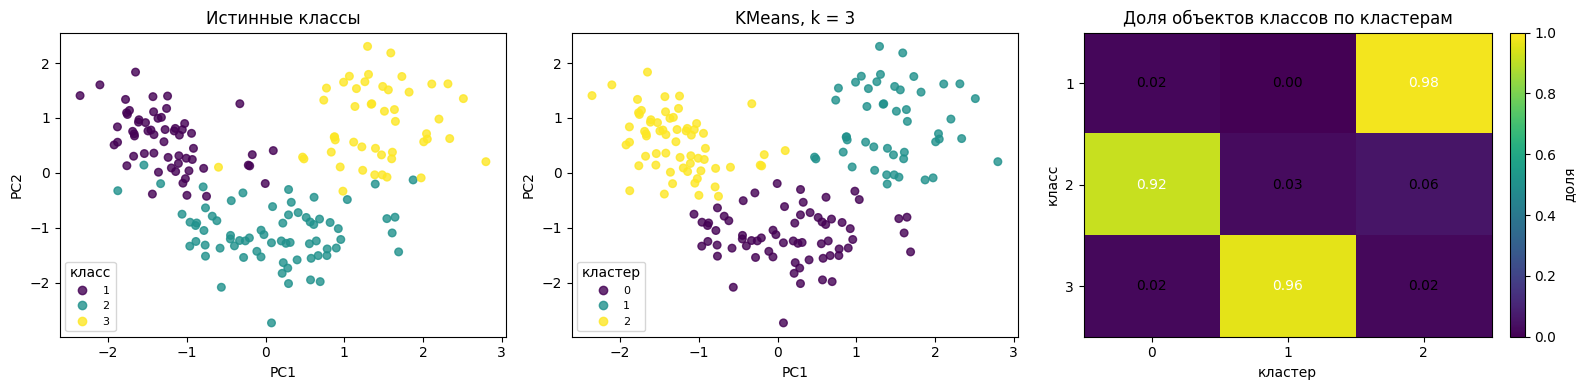

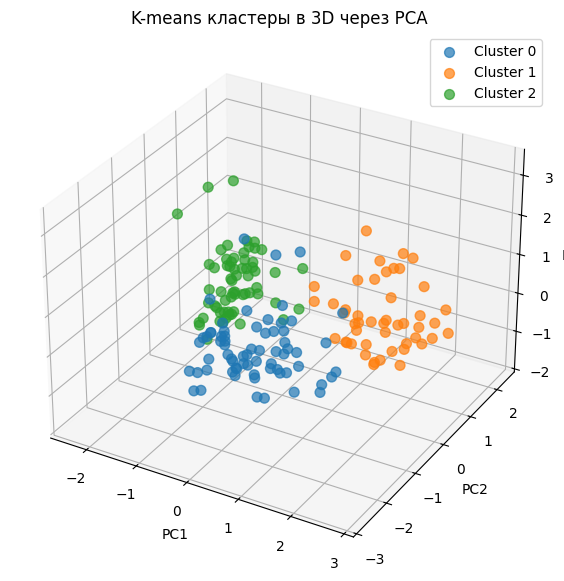

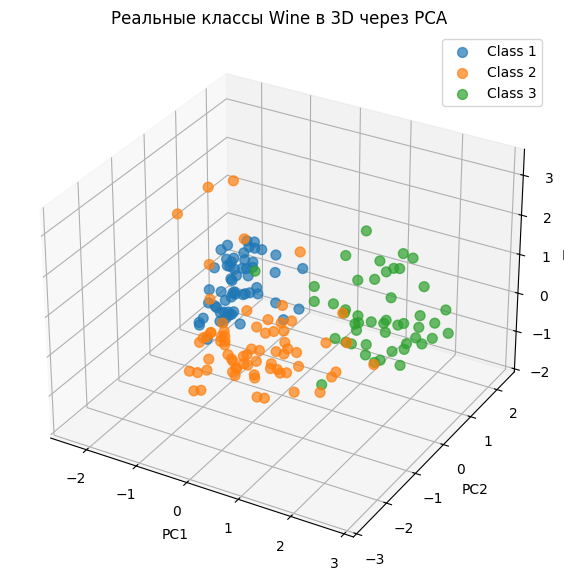

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

k = 3

kmeans = KMeans(
    n_clusters=k,
    init="k-means++",
    n_init=10,
    random_state=52,
)
kmeans.fit(X_std)
km_labels = kmeans.labels_

X_pca = PCA(n_components=2, random_state=52).fit_transform(X_std)

y = X_selected_std['Class'] = data['Class']
y_codes, y_classes = pd.factorize(y)

cm_counts = pd.crosstab(pd.Series(y, name="class"), pd.Series(km_labels, name="cluster"))
cm = cm_counts.div(cm_counts.sum(axis=1), axis=0)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_codes, s=30, alpha=0.8)
ax1.set_title("Истинные классы")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
handles1, _ = sc1.legend_elements()
ax1.legend(handles1, y_classes.astype(str), title="класс", loc="best", fontsize=8)

sc2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, s=30, alpha=0.8)
ax2.set_title(f"KMeans, k = {k}")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
handles2, _ = sc2.legend_elements()
ax2.legend(handles2, sorted(np.unique(km_labels)), title="кластер", loc="best", fontsize=8)

im = ax3.imshow(cm.values, vmin=0, vmax=1, aspect="auto", cmap="viridis")
ax3.set_title("Доля объектов классов по кластерам")
ax3.set_xlabel("кластер")
ax3.set_ylabel("класс")
ax3.set_xticks(np.arange(cm.shape[1]))
ax3.set_yticks(np.arange(cm.shape[0]))
ax3.set_xticklabels(cm.columns)
ax3.set_yticklabels(cm.index)

for (i, j), v in np.ndenumerate(cm.values):
    ax3.text(j, i, f"{v:.2f}", ha="center", va="center", color="white" if v > 0.5 else "black")

cbar = fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_label("доля", rotation=90)

plt.tight_layout()
plt.show()


X_pca3 = PCA(n_components=3, random_state=52).fit_transform(X_std)
pca3_df = pd.DataFrame(X_pca3, columns=["PC1", "PC2", "PC3"])
pca3_df["cluster"] = labels
pca3_df["class"] = y_true
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for c in sorted(pca3_df["cluster"].unique()):
    mask = pca3_df["cluster"] == c
    ax.scatter(
        pca3_df.loc[mask, "PC1"],
        pca3_df.loc[mask, "PC2"],
        pca3_df.loc[mask, "PC3"],
        s=50,
        alpha=0.7,
        label=f"Cluster {c}"
    )

ax.set_title("K-means кластеры в 3D через PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for cls in sorted(pca3_df["class"].unique()):
    mask = pca3_df["class"] == cls
    ax.scatter(
        pca3_df.loc[mask, "PC1"],
        pca3_df.loc[mask, "PC2"],
        pca3_df.loc[mask, "PC3"],
        s=50,
        alpha=0.7,
        label=f"Class {cls}"
    )

ax.set_title("Реальные классы Wine в 3D через PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.show()

## GMM

### Подбор параметров

Параметры GMM:

n_components: количество кластеров (гауссиан) — аналог k в KMeans. 

covariance_type: тип ковариационной матрицы для гауссиан. Варианты матрицы: 
- full: каждая компонента имеет свою полную ковариационную матрицу (может быть эллипсоидом любой формы и ориентации).
- tied: все компоненты используют одну и ту же полную ковариационную матрицу (одинаковая форма и ориентация для всех кластеров).
- diag: каждая компонента имеет свою диагональную ковариационную матрицу (эллипсоиды, но оси параллельны координатным осям).
- spherical: каждая компонента имеет свою ковариационную матрицу в виде числа, умноженного на единичную матрицу (сферические кластеры, как в KMeans, но с разными радиусами).  

Берем n_components = 3 и тип ковариационной матрицы – full, так как есть подозрение, что кластеры эллипсоидной формы.


<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

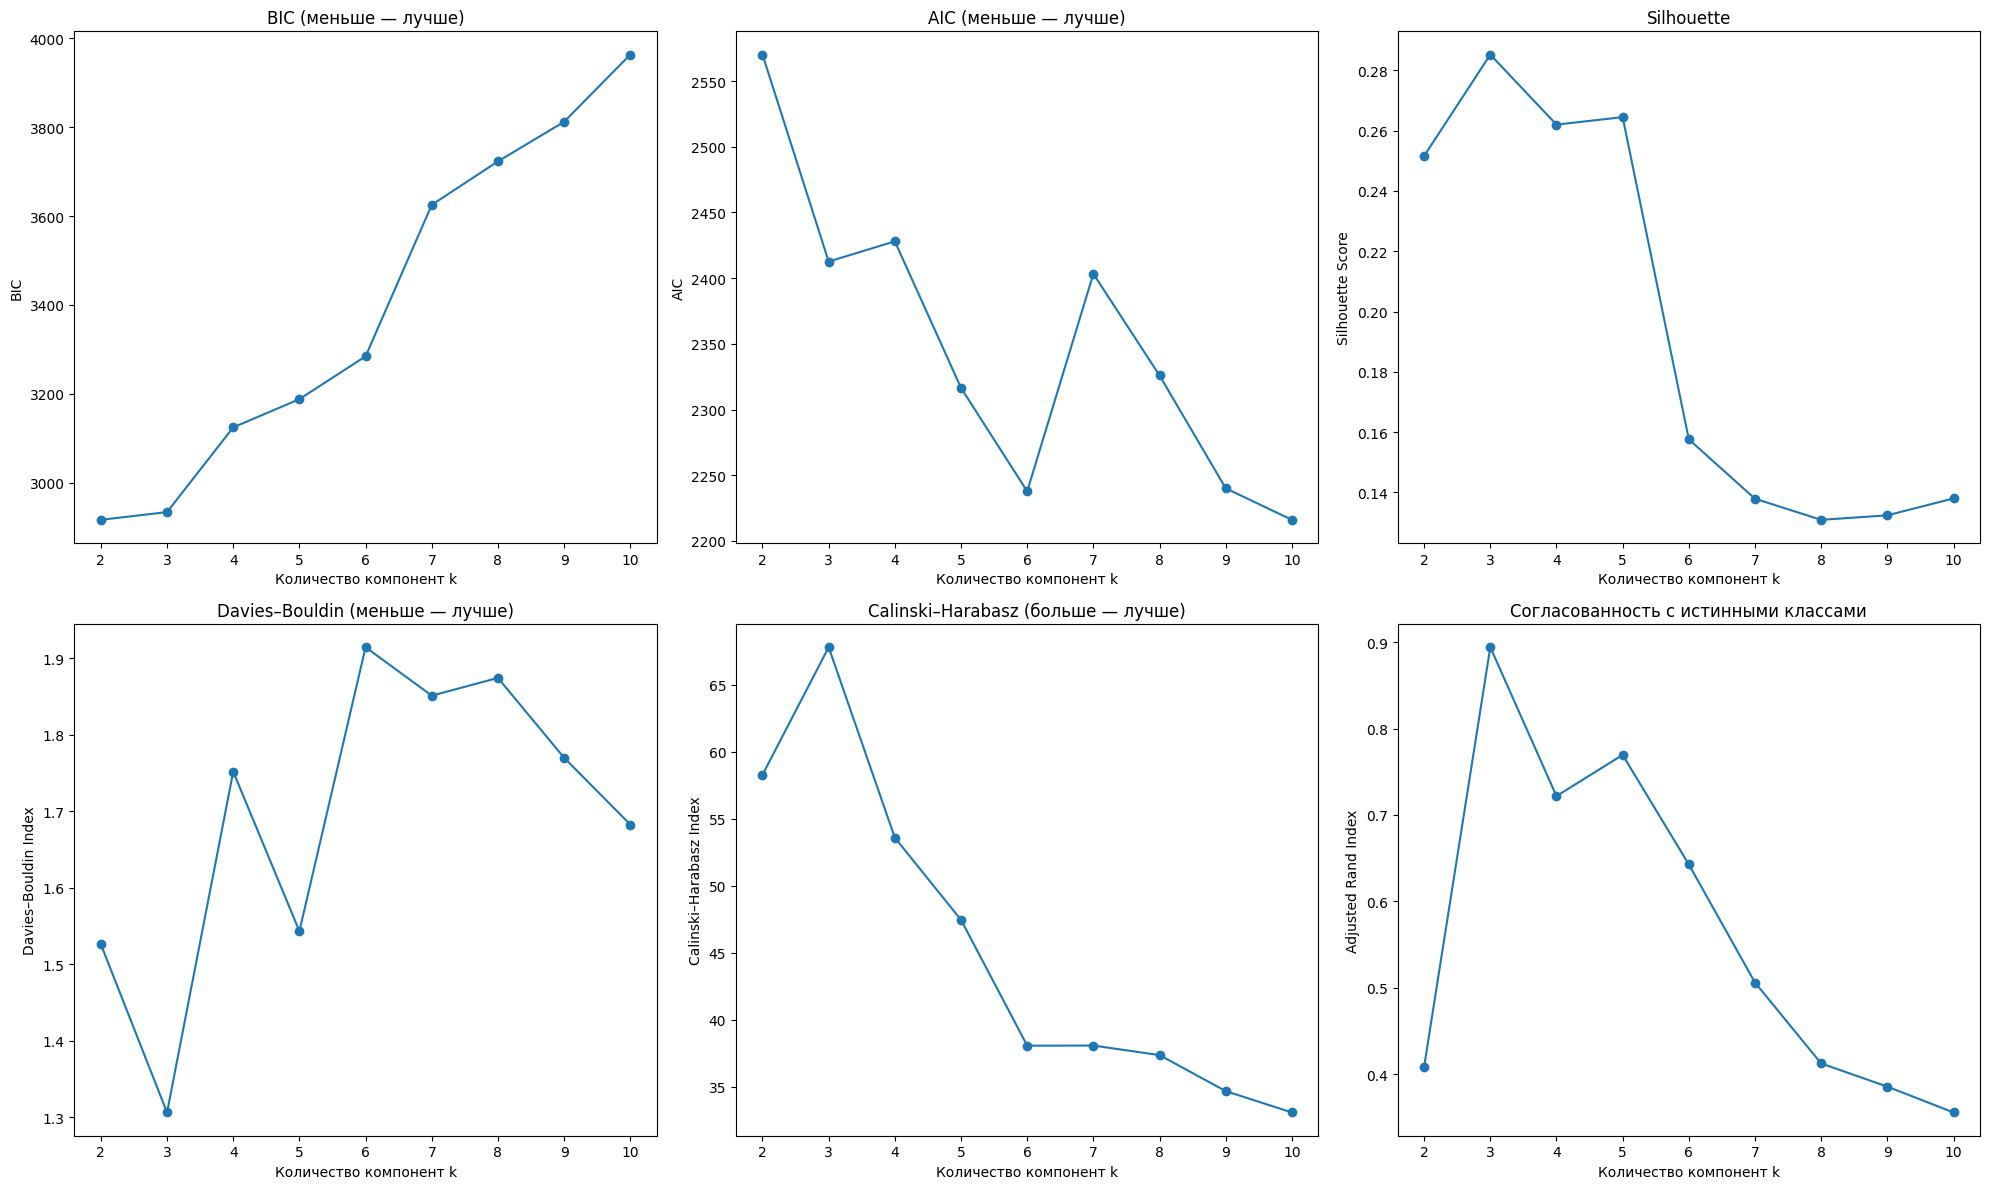

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

y_true = X_selected_std['Class']
X_cluster = X_selected_std.drop(columns=['Class'])

K_range = range(2, 11)

bic_scores = []
aic_scores = []
silhouette_scores = []
dbi_scores = []
chi_scores = []
ari_scores = []

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=52
    )
    
    gmm.fit(X_cluster)
    labels = gmm.predict(X_cluster)
    
    bic_scores.append(gmm.bic(X_cluster))
    aic_scores.append(gmm.aic(X_cluster))
    
    silhouette_scores.append(silhouette_score(X_cluster, labels))
    dbi_scores.append(davies_bouldin_score(X_cluster, labels))
    chi_scores.append(calinski_harabasz_score(X_cluster, labels))
    ari_scores.append(adjusted_rand_score(y_true, labels))

    plt.figure(figsize=(20,12))

plt.subplot(2,3,1)
plt.plot(K_range, bic_scores, 'o-')
plt.xlabel('Количество компонент k')
plt.ylabel('BIC')
plt.title('BIC (меньше — лучше)')


plt.subplot(2,3,2)
plt.plot(K_range, aic_scores, 'o-')
plt.xlabel('Количество компонент k')
plt.ylabel('AIC')
plt.title('AIC (меньше — лучше)')

# Silhouette
plt.subplot(2,3,3)
plt.plot(K_range, silhouette_scores, 'o-')
plt.xlabel('Количество компонент k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette')

# Davies–Bouldin
plt.subplot(2,3,4)
plt.plot(K_range, dbi_scores, 'o-')
plt.xlabel('Количество компонент k')
plt.ylabel('Davies–Bouldin Index')
plt.title('Davies–Bouldin (меньше — лучше)')

# Calinski–Harabasz
plt.subplot(2,3,5)
plt.plot(K_range, chi_scores, 'o-')
plt.xlabel('Количество компонент k')
plt.ylabel('Calinski–Harabasz Index')
plt.title('Calinski–Harabasz (больше — лучше)')

# ARI
plt.subplot(2,3,6)
plt.plot(K_range, ari_scores, 'o-')
plt.xlabel('Количество компонент k')
plt.ylabel('Adjusted Rand Index')
plt.title('Согласованность с истинными классами')

plt.tight_layout()
plt.show()



### Решение задачи кластеризации с помошью GMM

Метрики GMM (k = 4):
Средний силуэт           : 0.2965
Индекс Калински–Харабаса : 56.1596
Индекс Дэвиса–Болдина    : 1.3204
ARI                      : 0.9170
BIC                      : 2965.93
AIC                      : 2269.12

Расстояния между центрами кластеров (евклидовы):


,component_0,component_1,component_2,component_3
component_0,0.000000,3.175754,2.791657,2.435626
component_1,3.175754,0.000000,2.349085,2.538518
component_2,2.791657,2.349085,0.000000,2.322660
component_3,2.435626,2.538518,2.322660,0.000000


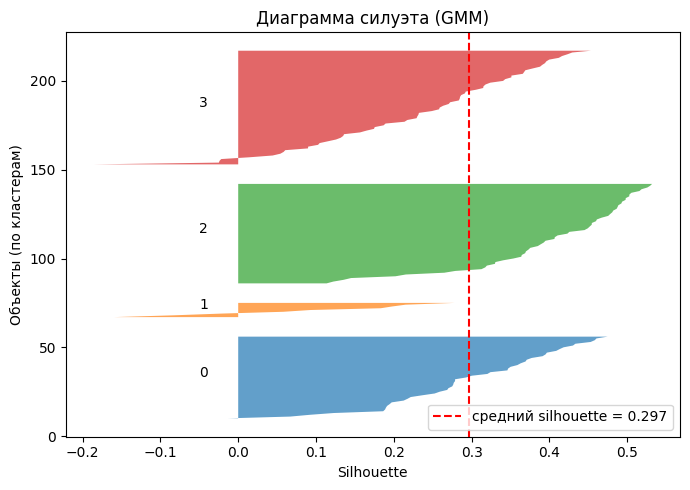

,Alcohol,Proline,Malic_acid,Alcalinity_of_ash,Magnesium,Flavanoids,Nonflavanoid_phenols,Color_intensity,Hue
component_0,0.083663,-0.090005,1.020966,0.462691,0.043716,-0.816459,0.671900,0.931720,-0.841286
component_1,-0.372625,0.255360,-0.173799,0.454782,1.970762,0.120759,-0.165838,-0.314318,0.376956
component_2,0.534416,0.916608,0.100365,-0.613321,0.395540,0.512201,-0.340124,0.291586,0.276083
component_3,-0.582769,-0.362004,0.069940,0.138734,-0.402038,-0.050156,0.193864,-0.549376,0.252645


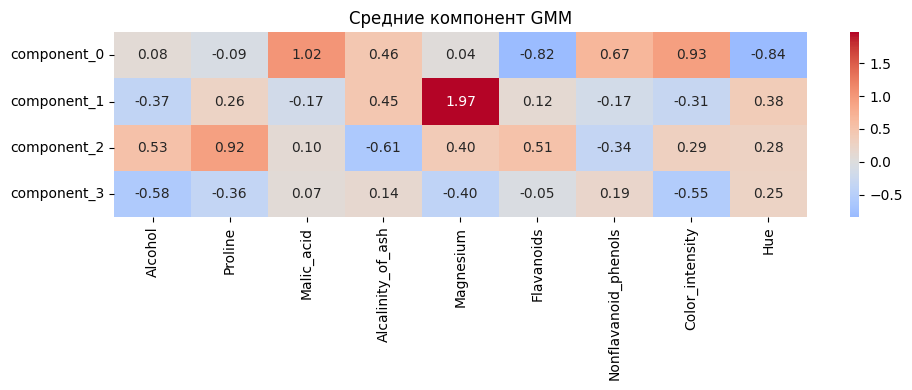

,component,size,mean_dist_to_mean,std_dist_to_mean
0,0,47,1.530901,0.398240
1,1,9,1.923736,0.439502
2,2,57,1.201602,0.346238
3,3,65,1.509801,0.497623


,feature,F_stat,p_value
0,Alcohol,83.862743,1.310133e-33
1,Proline,145.595608,3.218350e-47
2,Malic_acid,27.093067,1.986979e-14
3,Alcalinity_of_ash,27.989136,8.072771e-15
4,Magnesium,65.875553,1.650415e-28
5,Flavanoids,153.035254,1.427511e-48
6,Nonflavanoid_phenols,22.600158,2.094984e-12
7,Color_intensity,84.412152,9.372086e-34
8,Hue,65.146757,2.750624e-28


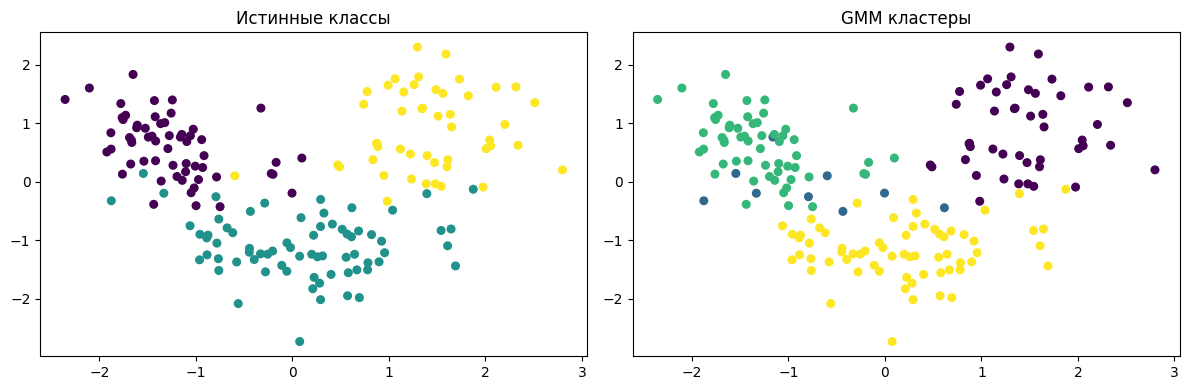

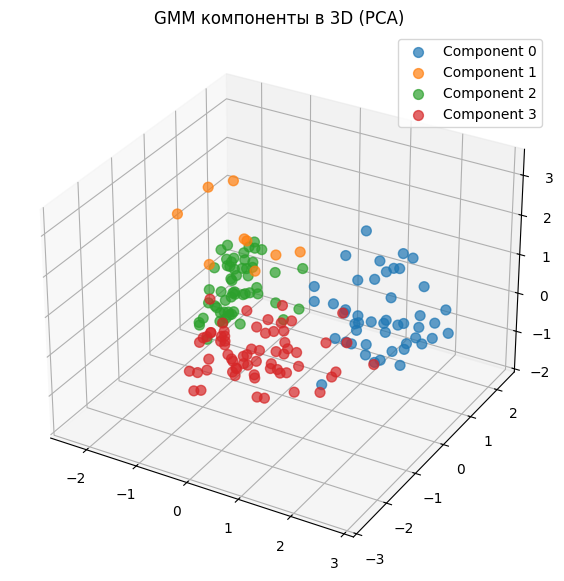

In [32]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_samples,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.decomposition import PCA
from scipy.stats import f_oneway
from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

X_scaled = X_std.copy()
y_true = X_selected_std['Class'] = data['Class']

k = 4
gmm = GaussianMixture(
    n_components=k,
    covariance_type="full",
    n_init=10,
    random_state=52
)

gmm.fit(X_scaled)

labels = gmm.predict(X_scaled)
proba = gmm.predict_proba(X_scaled)  # вероятности принадлежности
sil_samples = silhouette_samples(X_scaled, labels)
sil = silhouette_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ari = adjusted_rand_score(y_true, labels)

bic = gmm.bic(X_scaled)
aic = gmm.aic(X_scaled)

print(f"Метрики GMM (k = {k}):")
print(f"Средний силуэт           : {sil:.4f}")
print(f"Индекс Калински–Харабаса : {ch:.4f}")
print(f"Индекс Дэвиса–Болдина    : {db:.4f}")
print(f"ARI                      : {ari:.4f}")
print(f"BIC                      : {bic:.2f}")
print(f"AIC                      : {aic:.2f}")

# === ДОБАВЛЕННЫЙ КОД: Расстояния между центрами кластеров ===
print("\n" + "="*60)
print("Расстояния между центрами кластеров (евклидовы):")
print("="*60)

# Получаем центры кластеров (средние значения компонент)
centers = gmm.means_

# Вычисляем попарные евклидовы расстояния между центрами
center_distances = pairwise_distances(centers)

# Создаем DataFrame для отображения
dist_df = pd.DataFrame(
    center_distances,
    index=[f'component_{i}' for i in range(k)],
    columns=[f'component_{i}' for i in range(k)]
)

# Форматируем вывод (6 знаков после запятой)
formatted_dist_df = dist_df.copy()
for col in formatted_dist_df.columns:
    formatted_dist_df[col] = formatted_dist_df[col].apply(lambda x: f"{x:.6f}")

display(formatted_dist_df)

fig, ax = plt.subplots(figsize=(7, 5))

y_lower = 10
for c in range(k):
    sil_c = sil_samples[labels == c]
    sil_c.sort()
    size_c = sil_c.shape[0]
    y_upper = y_lower + size_c

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, sil_c,
        alpha=0.7,
    )
    ax.text(-0.05, y_lower + 0.5 * size_c, str(c))
    y_lower = y_upper + 10

ax.axvline(x=sil, color="red", linestyle="--",
           label=f"средний silhouette = {sil:.3f}")

ax.set_title("Диаграмма силуэта (GMM)")
ax.set_xlabel("Silhouette")
ax.set_ylabel("Объекты (по кластерам)")
ax.legend()
plt.tight_layout()
plt.show()

means = gmm.means_

means_df = pd.DataFrame(means, columns=X_scaled.columns)
means_df.index = [f"component_{c}" for c in range(k)]

display(means_df)

plt.figure(figsize=(10, 4))
sns.heatmap(
    means_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Средние компонент GMM")
plt.tight_layout()
plt.show()

dist_to_means = pairwise_distances(X_scaled, means)

cluster_stats = []
for c in range(k):
    mask = labels == c
    n_c = mask.sum()

    if n_c == 0:
        continue

    dists = dist_to_means[mask, c]

    cluster_stats.append({
        "component": c,
        "size": n_c,
        "mean_dist_to_mean": dists.mean(),
        "std_dist_to_mean": dists.std(),
    })

cluster_stats_df = pd.DataFrame(cluster_stats)
display(cluster_stats_df)

X_df = X_scaled.copy()
X_df["cluster"] = labels
X_df["class"] = y_true

feature_cols = [c for c in X_df.columns if c not in ["cluster", "class"]]

anova_rows = []
for feat in feature_cols:
    groups = [X_df.loc[labels == c, feat] for c in range(k) if (labels == c).sum() > 1]
    if len(groups) > 1:
        F, p = f_oneway(*groups)
    else:
        F, p = np.nan, np.nan

    anova_rows.append({
        "feature": feat,
        "F_stat": F,
        "p_value": p,
    })

anova_df = pd.DataFrame(anova_rows)
display(anova_df)

X_pca = PCA(n_components=2, random_state=52).fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Реальные классы
y_codes, y_classes = pd.factorize(y_true)
sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_codes, s=30)
ax1.set_title("Истинные классы")

# GMM
sc2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=30)
ax2.set_title("GMM кластеры")

plt.tight_layout()
plt.show()

X_pca3 = PCA(n_components=3, random_state=52).fit_transform(X_scaled)
pca3_df = pd.DataFrame(X_pca3, columns=["PC1", "PC2", "PC3"])
pca3_df["cluster"] = labels
pca3_df["class"] = y_true

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for c in sorted(pca3_df["cluster"].unique()):
    mask = pca3_df["cluster"] == c
    ax.scatter(
        pca3_df.loc[mask, "PC1"],
        pca3_df.loc[mask, "PC2"],
        pca3_df.loc[mask, "PC3"],
        s=50,
        alpha=0.7,
        label=f"Component {c}"
    )

ax.set_title("GMM компоненты в 3D (PCA)")
ax.legend()
plt.show()


Среднее расстояние до центра кластера варьируется от 1.41 до 1.56. Стандартное отклонение расстояния (std_dist_to_mean) от 0.43 до 0.62.  
Кластер 0: среднее расстояние 1.41, но при этом наибольшее стандартное отклонение (0.62) -> форма неоднородная, есть как близкие, так и далекие точки.
Кластер 2: самое большое среднее расстояние (1.56), но наименьшее стандартное отклонение (0.43) -> кластер более однородный, но менее компактный.

Теперь посмотрим на расстояния между кластерами.

 Наименьшее расстояние между центрами 0 и 1 (2.2355) сравнимо с размерами кластеров (сумма средних расстояний 1.41+1.53=2.94, что больше 2.2355).
Это может указывать на перекрытие кластеров 0 и 1

Индекс Калински-Харабаса составляет 67.79, а индекс Дэвиса-Болдина — 1.3063. Такое сочетание свидетельствует о достаточно выраженной кластерной структуре данных. Высокое значение индекса Калински-Харабаса указывает на то, что центры кластеров хорошо разнесены в пространстве, а сами кластеры обладают заметной компактностью. При этом индекс Дэвиса-Болдина, превышающий единицу, характерен для разбиения среднего качества — кластеры различимы, но между ними все еще наблюдается существенное перекрытие
Средний силуэт равен 0.2853, что соответствует умеренно хорошему качеству кластеризации. 

Посмотрим на силуэт диаграмму. 
 
Видно что часть точек попали не в свой кластер. В целом все три кластера имеют примерно одинаковое значение силуэта. 

Рассмотрим внешнюю метрику ARI. Ее значение равно 0.894.  
Это очень высокий результат. почти полное соответствие истинным классам. Он говорит о том, что GMM правильно уловил смысловую структуру данных.  
Это можно видеть на рисунке.  


### Сравнительный анализ решений

| Метрика | GMM (k = 3) | K-means (k = 3)|
|-------------|-------------|-------------|
| Средний силуэт    | 0.2853   | 0.2931    |
| Индекс Калински–Харабаса   | 67.7853    | 71.0148    |
| Индекс Дэвиса–Болдина   | 1.3063    | 1.2881   |
| ARI  | 0.8943   | 0.8486   |


У GMM Кластеры получились менее компактными, чем в Kmeans.  
При этом разброс внутри кластеров выше.  
Это ожидаемо: GMM с covariance_type=full позволяет кластерам иметь эллипсоидальную форму, что может приводить к большей вариативности расстояний до центра.
По внутренним метрикам (силуэт, CH, DB) K-means показывает немного лучшие результаты. Это означает, что с точки зрения геометрической структуры (компактность и разделимость) K-means дает более четкие кластеры.  
Однако по внешней метрике ARI, которая сравнивает с истинными метками, GMM явно лучше. Это говорит о том, что GMM лучше воспроизводит истинное разделение на классы, даже если геометрически кластеры выглядят немного хуже.  
Для данного датасета в прикладной задаче лучше использовать GMM как более интерпретируемую модель, несмотря на то что значения внутренних метрик несколько хуже.


### Исследование влияния параметров алгоритма на качество решения
Для метода GMM было проведено исследование влияния типа ковариационной матрицы (cov) и количества кластеров на метрики. Были построены графики зависимости метрик качества от числа кластеров k и типа ковариационной матрицы.

Исследование влияния параметров GMM на качество кластеризации
Данные: 178 объектов, 9 признаков
Истинные классы: 3
Обрабатываю k=2, covariance_type='full'...
Обрабатываю k=2, covariance_type='tied'...
Обрабатываю k=2, covariance_type='diag'...
Обрабатываю k=2, covariance_type='spherical'...
Обрабатываю k=3, covariance_type='full'...
Обрабатываю k=3, covariance_type='tied'...
Обрабатываю k=3, covariance_type='diag'...
Обрабатываю k=3, covariance_type='spherical'...
Обрабатываю k=4, covariance_type='full'...
Обрабатываю k=4, covariance_type='tied'...
Обрабатываю k=4, covariance_type='diag'...
Обрабатываю k=4, covariance_type='spherical'...
Обрабатываю k=5, covariance_type='full'...
Обрабатываю k=5, covariance_type='tied'...
Обрабатываю k=5, covariance_type='diag'...
Обрабатываю k=5, covariance_type='spherical'...
Обрабатываю k=6, covariance_type='full'...
Обрабатываю k=6, covariance_type='tied'...
Обрабатываю k=6, covariance_type='diag'...
Обрабатываю k=6, covariance_type='spherical'...


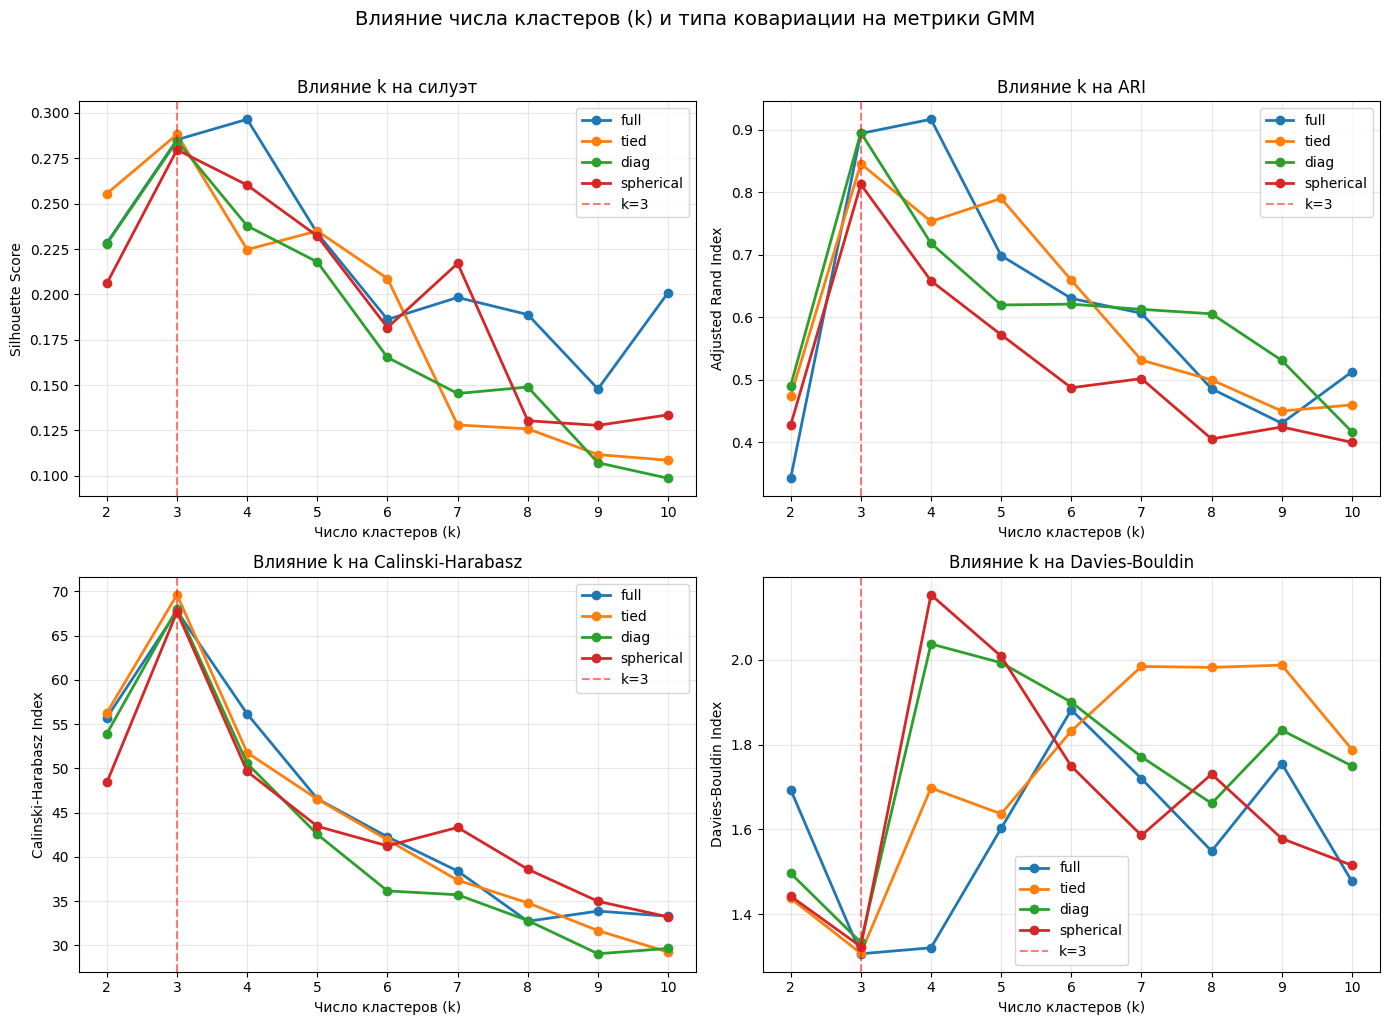


3. Тепловая карта ARI по параметрам...


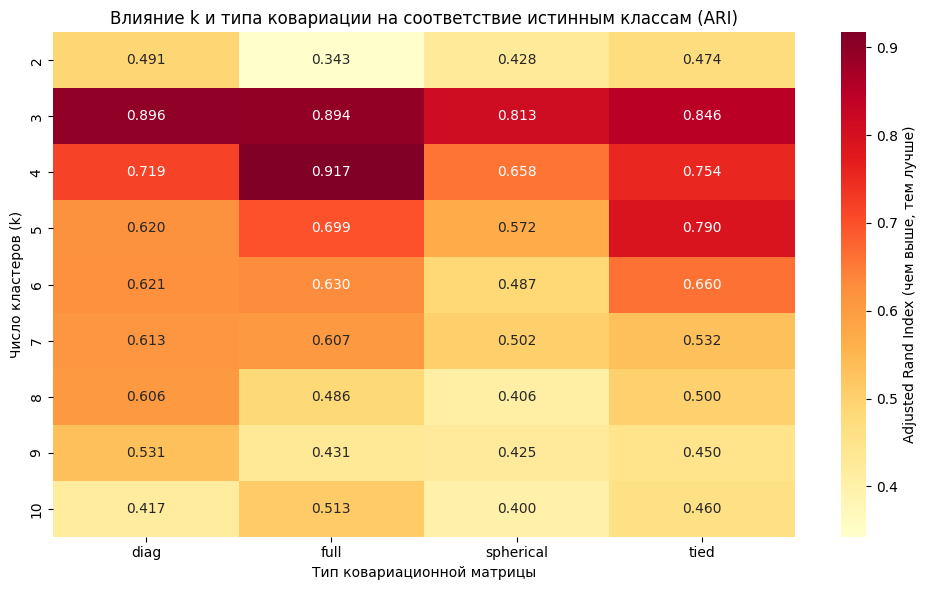


4. Информационные критерии BIC и AIC для выбора оптимального k...


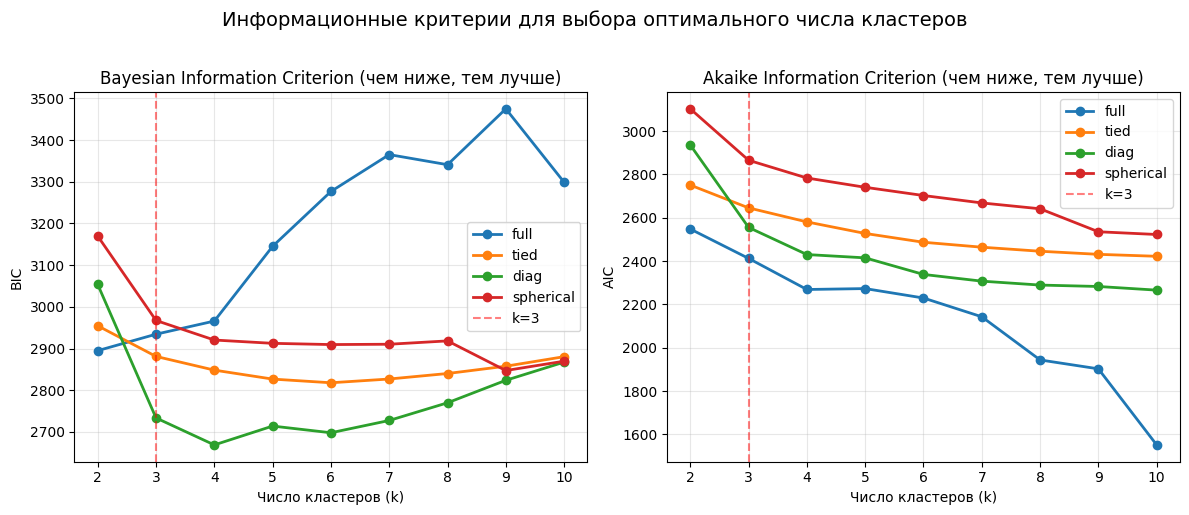


ЛУЧШИЕ КОМБИНАЦИИ ПАРАМЕТРОВ ПО РАЗНЫМ МЕТРИКАМ

Лучший силуэт:
  k=4, cov='full'
  Силуэт = 0.2965, ARI = 0.9170

Лучший ARI (соответствие истинным классам):
  k=4, cov='full'
  ARI = 0.9170, Силуэт = 0.2965

Лучший Calinski-Harabasz:
  k=3, cov='tied'
  CH = 69.6222, ARI = 0.8459

Лучший Davies-Bouldin (наименьшее значение):
  k=3, cov='full'
  DB = 1.3063, ARI = 0.8943

Минимальный BIC:
  k=4, cov='diag'
  BIC = 2669.01, ARI = 0.7187

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (k=2-10)

Всего комбинаций: 36
Лучший ARI: 0.9170 при k=4, cov='full'

ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ ИСХОДНЫХ ПАРАМЕТРОВ (k=3, cov='full')

Метрики GMM (k = 3, cov = 'full'):
Средний силуэт           : 0.2853
Индекс Калински–Харабаса : 67.7853
Индекс Дэвиса–Болдина    : 1.3063
ARI                      : 0.8943
BIC                      : 2934.46
AIC                      : 2412.65

Сравнение с результатами исследования:
  Силуэт: ваш = 0.2853, исследование = 0.2853
  ARI: ваш = 0.8943, исследование = 0.8943
  Разница BIC: 0.00

СОХРАН

In [33]:


from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_samples,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.decomposition import PCA
from scipy.stats import f_oneway
from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


X_scaled = X_std.copy()
y_true = X_selected_std['Class'] = data['Class']


X_arr = np.asarray(X_scaled)
y_arr = np.asarray(y_true)


k_values = range(2, 11) 
cov_types = ["full", "tied", "diag", "spherical"]

print("Исследование влияния параметров GMM на качество кластеризации")
print("=" * 60)
print(f"Данные: {X_arr.shape[0]} объектов, {X_arr.shape[1]} признаков")
print(f"Истинные классы: {len(np.unique(y_arr))}")
print("=" * 60)

results_list = []

for k in k_values:
    for cov_type in cov_types:
        print(f"Обрабатываю k={k}, covariance_type='{cov_type}'...")
        
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov_type,
            n_init=10,
            random_state=52,
            max_iter=100
        )
        
        gmm.fit(X_arr)

        labels = gmm.predict(X_arr)
        
        try:
            sil = silhouette_score(X_arr, labels)
        except:
            sil = np.nan
            
        try:
            ch = calinski_harabasz_score(X_arr, labels)
        except:
            ch = np.nan
            
        try:
            db = davies_bouldin_score(X_arr, labels)
        except:
            db = np.nan
            
        try:
            ari = adjusted_rand_score(y_arr, labels)
        except:
            ari = np.nan
        
        bic = gmm.bic(X_arr)
        aic = gmm.aic(X_arr)
        
        results_list.append({
            'k': k,
            'covariance_type': cov_type,
            'silhouette': sil,
            'calinski_harabasz': ch,
            'davies_bouldin': db,
            'ari': ari,
            'bic': bic,
            'aic': aic,
            'converged': gmm.converged_,
            'n_iter': gmm.n_iter_
        })

results_df = pd.DataFrame(results_list)

print("\n" + "="*60)
print("ОСНОВНЫЕ РЕЗУЛЬТАТЫ ИССЛЕДОВАНИЯ")
print("="*60)

print("\n1. Результаты для k=3 (сравнение с вашим исходным анализом):")
print("-" * 50)

k3_results = results_df[results_df['k'] == 3].copy()
for cov_type in cov_types:
    row = k3_results[k3_results['covariance_type'] == cov_type].iloc[0]
    print(f"\n  covariance_type='{cov_type}':")
    print(f"    Силуэт: {row['silhouette']:.4f}")
    print(f"    Calinski-Harabasz: {row['calinski_harabasz']:.4f}")
    print(f"    Davies-Bouldin: {row['davies_bouldin']:.4f}")
    print(f"    ARI: {row['ari']:.4f}")
    print(f"    BIC: {row['bic']:.2f}")
    print(f"    AIC: {row['aic']:.2f}")
print("\n2. Визуализация результатов...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Силуэт по k
ax = axes[0, 0]
for cov_type in cov_types:
    subset = results_df[results_df['covariance_type'] == cov_type]
    ax.plot(subset['k'], subset['silhouette'], marker='o', label=cov_type, linewidth=2)
ax.set_xlabel('Число кластеров (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Влияние k на силуэт')
ax.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='k=3')
ax.grid(True, alpha=0.3)
ax.legend()

# График 2: ARI по k
ax = axes[0, 1]
for cov_type in cov_types:
    subset = results_df[results_df['covariance_type'] == cov_type]
    ax.plot(subset['k'], subset['ari'], marker='o', label=cov_type, linewidth=2)
ax.set_xlabel('Число кластеров (k)')
ax.set_ylabel('Adjusted Rand Index')
ax.set_title('Влияние k на ARI')
ax.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='k=3')
ax.grid(True, alpha=0.3)
ax.legend()

# График 3: Calinski-Harabasz по k
ax = axes[1, 0]
for cov_type in cov_types:
    subset = results_df[results_df['covariance_type'] == cov_type]
    ax.plot(subset['k'], subset['calinski_harabasz'], marker='o', label=cov_type, linewidth=2)
ax.set_xlabel('Число кластеров (k)')
ax.set_ylabel('Calinski-Harabasz Index')
ax.set_title('Влияние k на Calinski-Harabasz')
ax.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='k=3')
ax.grid(True, alpha=0.3)
ax.legend()

# График 4: Davies-Bouldin по k
ax = axes[1, 1]
for cov_type in cov_types:
    subset = results_df[results_df['covariance_type'] == cov_type]
    ax.plot(subset['k'], subset['davies_bouldin'], marker='o', label=cov_type, linewidth=2)
ax.set_xlabel('Число кластеров (k)')
ax.set_ylabel('Davies-Bouldin Index')
ax.set_title('Влияние k на Davies-Bouldin')
ax.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='k=3')
ax.grid(True, alpha=0.3)
ax.legend()

plt.suptitle('Влияние числа кластеров (k) и типа ковариации на метрики GMM', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 3. Тепловая карта ARI по k и типу ковариации
print("\n3. Тепловая карта ARI по параметрам...")

# Создаем сводную таблицу для ARI
pivot_ari = results_df.pivot(index='k', columns='covariance_type', values='ari')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_ari, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Adjusted Rand Index (чем выше, тем лучше)'})
plt.title('Влияние k и типа ковариации на соответствие истинным классам (ARI)')
plt.xlabel('Тип ковариационной матрицы')
plt.ylabel('Число кластеров (k)')
plt.tight_layout()
plt.show()

# 4. Анализ информационных критериев BIC и AIC
print("\n4. Информационные критерии BIC и AIC для выбора оптимального k...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# BIC по k
for cov_type in cov_types:
    subset = results_df[results_df['covariance_type'] == cov_type]
    ax1.plot(subset['k'], subset['bic'], marker='o', label=cov_type, linewidth=2)

ax1.set_xlabel('Число кластеров (k)')
ax1.set_ylabel('BIC')
ax1.set_title('Bayesian Information Criterion (чем ниже, тем лучше)')
ax1.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='k=3')
ax1.grid(True, alpha=0.3)
ax1.legend()

# AIC по k
for cov_type in cov_types:
    subset = results_df[results_df['covariance_type'] == cov_type]
    ax2.plot(subset['k'], subset['aic'], marker='o', label=cov_type, linewidth=2)

ax2.set_xlabel('Число кластеров (k)')
ax2.set_ylabel('AIC')
ax2.set_title('Akaike Information Criterion (чем ниже, тем лучше)')
ax2.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='k=3')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle('Информационные критерии для выбора оптимального числа кластеров', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 5. Находим лучшие комбинации параметров
print("\n" + "="*60)
print("ЛУЧШИЕ КОМБИНАЦИИ ПАРАМЕТРОВ ПО РАЗНЫМ МЕТРИКАМ")
print("="*60)

# Удаляем строки с NaN значениями
results_clean = results_df.dropna()

# Лучший силуэт
best_sil = results_clean.loc[results_clean['silhouette'].idxmax()]
print(f"\nЛучший силуэт:")
print(f"  k={int(best_sil['k'])}, cov='{best_sil['covariance_type']}'")
print(f"  Силуэт = {best_sil['silhouette']:.4f}, ARI = {best_sil['ari']:.4f}")

# Лучший ARI
best_ari = results_clean.loc[results_clean['ari'].idxmax()]
print(f"\nЛучший ARI (соответствие истинным классам):")
print(f"  k={int(best_ari['k'])}, cov='{best_ari['covariance_type']}'")
print(f"  ARI = {best_ari['ari']:.4f}, Силуэт = {best_ari['silhouette']:.4f}")

# Лучший Calinski-Harabasz
best_ch = results_clean.loc[results_clean['calinski_harabasz'].idxmax()]
print(f"\nЛучший Calinski-Harabasz:")
print(f"  k={int(best_ch['k'])}, cov='{best_ch['covariance_type']}'")
print(f"  CH = {best_ch['calinski_harabasz']:.4f}, ARI = {best_ch['ari']:.4f}")

# Лучший Davies-Bouldin (минимальное значение)
best_db = results_clean.loc[results_clean['davies_bouldin'].idxmin()]
print(f"\nЛучший Davies-Bouldin (наименьшее значение):")
print(f"  k={int(best_db['k'])}, cov='{best_db['covariance_type']}'")
print(f"  DB = {best_db['davies_bouldin']:.4f}, ARI = {best_db['ari']:.4f}")

# Минимальный BIC
best_bic = results_clean.loc[results_clean['bic'].idxmin()]
print(f"\nМинимальный BIC:")
print(f"  k={int(best_bic['k'])}, cov='{best_bic['covariance_type']}'")
print(f"  BIC = {best_bic['bic']:.2f}, ARI = {best_bic['ari']:.4f}")

# 6. Сводная таблица результатов
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (k=2-10)")
print("="*60)

# Группируем по k и типу ковариации
summary_stats = results_clean.groupby(['k', 'covariance_type']).agg({
    'silhouette': 'mean',
    'ari': 'mean',
    'calinski_harabasz': 'mean',
    'davies_bouldin': 'mean',
    'bic': 'mean',
    'aic': 'mean'
}).round(4).reset_index()

print(f"\nВсего комбинаций: {len(results_clean)}")
print(f"Лучший ARI: {best_ari['ari']:.4f} при k={int(best_ari['k'])}, cov='{best_ari['covariance_type']}'")

# 7. Детальный анализ для вашего исходного случая (k=3, full)
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ ИСХОДНЫХ ПАРАМЕТРОВ (k=3, cov='full')")
print("="*60)

# Запускаем GMM с вашими исходными параметрами
k = 3
cov_type = 'full'

gmm_original = GaussianMixture(
    n_components=k,
    covariance_type=cov_type,
    n_init=10,
    random_state=52
)

gmm_original.fit(X_scaled)
labels_original = gmm_original.predict(X_scaled)

# Вычисляем все метрики как в вашем исходном коде
sil_samples = silhouette_samples(X_scaled, labels_original)
sil = silhouette_score(X_scaled, labels_original)
ch = calinski_harabasz_score(X_scaled, labels_original)
db = davies_bouldin_score(X_scaled, labels_original)
ari = adjusted_rand_score(y_true, labels_original)
bic = gmm_original.bic(X_scaled)
aic = gmm_original.aic(X_scaled)

print(f"\nМетрики GMM (k = {k}, cov = '{cov_type}'):")
print(f"Средний силуэт           : {sil:.4f}")
print(f"Индекс Калински–Харабаса : {ch:.4f}")
print(f"Индекс Дэвиса–Болдина    : {db:.4f}")
print(f"ARI                      : {ari:.4f}")
print(f"BIC                      : {bic:.2f}")
print(f"AIC                      : {aic:.2f}")

# Проверяем, совпадает ли с результатами исследования
research_result = results_df[(results_df['k'] == k) & (results_df['covariance_type'] == cov_type)].iloc[0]
print(f"\nСравнение с результатами исследования:")
print(f"  Силуэт: ваш = {sil:.4f}, исследование = {research_result['silhouette']:.4f}")
print(f"  ARI: ваш = {ari:.4f}, исследование = {research_result['ari']:.4f}")
print(f"  Разница BIC: {abs(bic - research_result['bic']):.2f}")

# 8. Сохранение результатов
print("\n" + "="*60)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*60)

# Сохраняем DataFrame с результатами
results_df.to_csv('gmm_parameter_study_exact.csv', index=False)
print(f"Результаты сохранены в файл: gmm_parameter_study_exact.csv")
print(f"Всего исследовано комбинаций: {len(results_df)}")

# 9. Рекомендации по выбору параметров
print("\n" + "="*60)
print("РЕКОМЕНДАЦИИ ПО ВЫБОРУ ПАРАМЕТРОВ")
print("="*60)

print("\nНа основе исследования параметров GMM:")

# Если лучший ARI отличается от k=3
if best_ari['k'] != 3 or best_ari['covariance_type'] != 'full':
    print(f"1. Лучшее соответствие истинным классам (ARI) достигается при:")
    print(f"   k = {int(best_ari['k'])}, covariance_type = '{best_ari['covariance_type']}'")
    print(f"   ARI = {best_ari['ari']:.4f} (улучшение на {best_ari['ari'] - ari:.4f} относительно k=3, full)")
    
print(f"\n2. Для вашего исходного случая (k=3, full):")
print(f"   ARI = {ari:.4f}, Силуэт = {sil:.4f}")

print(f"\n3. По информационным критериям (BIC/AIC):")
print(f"   Рекомендуемое k по BIC: {int(best_bic['k'])}")
print(f"   Рекомендуемое k по AIC: {int(results_clean.loc[results_clean['aic'].idxmin()]['k'])}")

print(f"\n4. Общая рекомендация:")
if best_ari['ari'] > ari + 0.02:  # Если улучшение существенное
    print(f"   Рассмотрите использование k={int(best_ari['k'])} с covariance_type='{best_ari['covariance_type']}'")
else:
    print(f"   Параметры k=3, covariance_type='full' дают хорошие результаты и могут быть сохранены")

На графике видно, что для всех типов ковариационных матриц силуэт достигает пика при k=3, кроме типа full, где пик при k = 4, затем снижается. При k=4 значение силуэта уже ниже, чем при k=3, и продолжает снижаться с ростом k.  
Тип ковариационной матрицы: full и tied показывают схожие результаты, diag и spherical - несколько ниже.  

Максимальный ARI достигается для всех ковариаций в точке k  = 3, дальше идет спад для всех типов кроме full, хотя в этом случае рост незначительный.   

По индексу Калински–Харабаса (CH) для всех ковариаций наблюдается максимум в области k = 3. Пик CH в k= 3 говорит, что именно тут достигается хороший компромисс между компактностью внутри кластеров и разбросом между ними. Все типы ковариационной матрицы показывают схожие результаты.  

Индекс Дэвиса–Болдина (DB) во всех вариантах показывает лучшее значение (наименьшее) в точке k =3. Дальше происходит резкий рост для всех типов матрицы. Для типа full схожее значение индекса достигается также при k=4.  

В целом можно сказать что число кластеров k = 3 и тип ковариационной матрицы full были выбраны правильно, они обеспечивают максимальные значения метрик.  
